<a href="https://colab.research.google.com/github/juborduchi/governanca-digital_mre/blob/main/notebooks/analise_discursos_artigos_entrevistas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importação das bibliotecas

In [ ]:
import os
import json
import pandas as pd
import glob

!pip install wordcloud -q

# Acesso ao drive

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


# Organização dos JSONs na DataFrame

In [ ]:
def consolidar_jsons_aninhados(caminho_diretorio):
    lista_dataframes = []

    # Listar arquivos
    arquivos = [f for f in os.listdir(caminho_diretorio) if f.endswith('.json')]

    if not arquivos:
        print("Nenhum arquivo JSON encontrado.")
        return None

    for arquivo in arquivos:
        caminho_completo = os.path.join(caminho_diretorio, arquivo)

        try:
            with open(caminho_completo, 'r', encoding='utf-8') as f:
                dados = json.load(f)

                # EXPLICAÇÃO TÉCNICA:
                # Se o seu JSON tem o formato {'_default': {'0': {...}, '1': {...}}},
                # precisamos extrair os valores da chave '_default'.
                if '_default' in dados:
                    # Transformamos os valores de '_default' em uma lista e normalizamos
                    conteudo = list(dados['_default'].values())
                    df_temp = pd.json_normalize(conteudo)
                else:
                    # Caso o JSON seja uma lista direta ou outra estrutura
                    df_temp = pd.json_normalize(dados)

                lista_dataframes.append(df_temp)
        except Exception as e:
            print(f"Erro ao processar {arquivo}: {e}")

    # Concatenar todos os arquivos processados
    df_final = pd.concat(lista_dataframes, ignore_index=True)

    # Limpeza de listas: Se os dados vierem como ['Brasil'], removemos os parênteses
    # Aplicamos uma função que extrai o primeiro elemento se o dado for uma lista
    df_final = df_final.applymap(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else x)

    return df_final

# --- CONFIGURAÇÃO DO CAMINHO ---
caminho_pasta = '/content/gdrive/MyDrive/Colab_Notebooks/pibic-2025-2026/json-discursos-artigos-entrevistas/'

# Execução
df = consolidar_jsons_aninhados(caminho_pasta)

# Exibição do resultado
if df is not None:
    print("DataFrame Organizado:")
    display(df.head())

DataFrame Organizado:


/tmp/ipykernel_597/3899459654.py:38: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_final = df_final.applymap(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else x)


,tipo_dado,pais,origem,sigla,classificado,categoria,autoria,titulo,subtitulo,data,...,nome_arquivo,dir_arquivo,dir_base,codigo_bd,dir_bd,nome_arq_bd,env_dir_bd,extra_01,extra_02,extra_03
0,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,carlos-alberto-franco-franca,Intervenção do senhor Ministro de Estado na ab...,"Brasília, 05 de outubro de 2022",05/10/2022,...,NA,NA,/hdvm12,bd/003/001/001/001/002/010,/json/,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,ministro-das-relacoes-exteriores,NA,NA
1,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,carlos-alberto-franco-franca,Discurso do senhor Ministro de Estado para tra...,17 de novembro de 2022,17/11/2022,...,NA,NA,/hdvm12,bd/003/001/001/001/002/010,/json/,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,ministro-das-relacoes-exteriores,NA,NA
2,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,carlos-alberto-franco-franca,Intervenção do Ministro Carlos França na Reuni...,NA,08/11/2022,...,NA,NA,/hdvm12,bd/003/001/001/001/002/010,/json/,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,ministro-das-relacoes-exteriores,NA,NA
3,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,carlos-alberto-franco-franca,Intervenção do Ministro Carlos França na Cerim...,NA,31/05/2021,...,NA,NA,/hdvm12,bd/003/001/001/001/002/010,/json/,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,ministro-das-relacoes-exteriores,NA,NA
4,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,carlos-alberto-franco-franca,Intervenção do Ministro Carlos França pela cel...,NA,25/05/2021,...,NA,NA,/hdvm12,bd/003/001/001/001/002/010,/json/,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,ministro-das-relacoes-exteriores,NA,NA


# Preparação dos dados para análise

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1.1 — Converter data para datetime (dayfirst pq é formato brasileiro: dd/mm/aaaa)
df['data_dt'] = pd.to_datetime(df['data'], dayfirst=True, errors='coerce')

# 1.2 — Juntar os parágrafos (que são listas) em um único texto
df['texto'] = df['paragrafos'].apply(lambda lista: ' '.join(lista) if isinstance(lista, list) else str(lista))

# 1.3 — Coluna com tudo junto e em minúsculas (facilita buscas)
df['texto_completo'] = (df['titulo'].fillna('') + ' ' + df['texto']).str.lower()

# 1.4 — Extrair a hora como número inteiro (de "19h20" tira o 19)
df['hora_int'] = df['horario'].str.extract(r'(\d{1,2})').astype(float)

# 1.5 — Colunas auxiliares de tempo
df['ano_mes'] = df['data_dt'].dt.to_period('M')
df['dia_semana'] = df['data_dt'].dt.day_name()
df['tamanho_texto'] = df['texto'].str.len()
df['qtd_paragrafos'] = df['paragrafos'].apply(lambda x: len(x) if isinstance(x, list) else 0)

print(f"Total de arquivos: {len(df)}")
print(f"Período: de {df['data_dt'].min().date()} até {df['data_dt'].max().date()}")
df[['titulo', 'data_dt', 'hora_int', 'qtd_paragrafos', 'tamanho_texto']].head()

Total de arquivos: 2449
Período: de 2014-01-01 até 2025-12-31


,titulo,data_dt,hora_int,qtd_paragrafos,tamanho_texto
0,Intervenção do senhor Ministro de Estado na ab...,2022-10-05,0.0,0,81
1,Discurso do senhor Ministro de Estado para tra...,2022-11-17,0.0,0,20
2,Intervenção do Ministro Carlos França na Reuni...,2022-11-08,13.0,0,17
3,Intervenção do Ministro Carlos França na Cerim...,2021-05-31,11.0,0,31
4,Intervenção do Ministro Carlos França pela cel...,2021-05-25,16.0,0,128


In [ ]:
df_discursos = df[(df['categoria'].astype(str).str.contains('discursos'))]
df_discursos

,tipo_dado,pais,origem,sigla,classificado,categoria,autoria,titulo,subtitulo,data,...,extra_02,extra_03,data_dt,texto,texto_completo,hora_int,ano_mes,dia_semana,tamanho_texto,qtd_paragrafos
0,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,carlos-alberto-franco-franca,Intervenção do senhor Ministro de Estado na ab...,"Brasília, 05 de outubro de 2022",05/10/2022,...,NA,NA,2022-10-05,Não posso deixar de observar a representativid...,intervenção do senhor ministro de estado na ab...,0.0,2022-10,Wednesday,81,0
1,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,carlos-alberto-franco-franca,Discurso do senhor Ministro de Estado para tra...,17 de novembro de 2022,17/11/2022,...,NA,NA,2022-11-17,"Senhoras e senhores,",discurso do senhor ministro de estado para tra...,0.0,2022-11,Thursday,20,0
2,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,carlos-alberto-franco-franca,Intervenção do Ministro Carlos França na Reuni...,NA,08/11/2022,...,NA,NA,2022-11-08,"Thank you, Chair.",intervenção do ministro carlos frança na reuni...,13.0,2022-11,Tuesday,17,0
3,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,carlos-alberto-franco-franca,Intervenção do Ministro Carlos França na Cerim...,NA,31/05/2021,...,NA,NA,2021-05-31,"Senhor Presidente da República,",intervenção do ministro carlos frança na cerim...,11.0,2021-05,Monday,31,0
4,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,carlos-alberto-franco-franca,Intervenção do Ministro Carlos França pela cel...,NA,25/05/2021,...,NA,NA,2021-05-25,"Muito obrigado, Embaixador Martin Mbeng, pelas...",intervenção do ministro carlos frança pela cel...,16.0,2021-05,Tuesday,128,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2427,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,luiz-inacio-lula-da-silva-2003-2011,Discurso durante jantar oferecido pelo Preside...,NA,17/11/2025,...,NA,NA,2025-11-17,Foi com grande prazer que atendi o convite de ...,discurso durante jantar oferecido pelo preside...,18.0,2025-11,Monday,145,0
2428,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,luiz-inacio-lula-da-silva-2003-2011,Discurso durante cerimônia de assinatura de at...,NA,17/11/2025,...,NA,NA,2025-11-17,"É uma alegria imensa do meu Governo estar, nes...",discurso durante cerimônia de assinatura de at...,18.0,2025-11,Monday,135,0
2429,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,luiz-inacio-lula-da-silva-2003-2011,Discurso na recepção oferecida pela família ga...,NA,17/11/2025,...,NA,NA,2025-11-17,Acredito que poucos brasileiros tenham tido a ...,discurso na recepção oferecida pela família ga...,18.0,2025-11,Monday,173,0
2430,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,luiz-inacio-lula-da-silva-2003-2011,Declaração à Imprensa após cerimônia de assina...,NA,17/11/2025,...,NA,NA,2025-11-17,"Eu gostaria, primeiro, de agradecer ao Preside...",declaração à imprensa após cerimônia de assina...,17.0,2025-11,Monday,142,0


In [ ]:
df_artigos = df[(df['categoria'].astype(str).str.contains('artigos'))]
df_artigos

,tipo_dado,pais,origem,sigla,classificado,categoria,autoria,titulo,subtitulo,data,...,extra_02,extra_03,data_dt,texto,texto_completo,hora_int,ano_mes,dia_semana,tamanho_texto,qtd_paragrafos
1038,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,artigos,luiz-inacio-lula-da-silva-2023-2026,Brasil e África: parceria histórica contra a fome,Artigo do presidente Luiz Inácio Lula da Silva...,23/05/2025,...,NA,NA,2025-05-23,A humanidade não tem o direito de deixar 733 m...,brasil e áfrica: parceria histórica contra a f...,7.0,2025-05,Friday,474,0
1039,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,artigos,luiz-inacio-lula-da-silva-2023-2026,Opinion: L’Afrique fait partie du Brésil et le...,NA,23/05/2025,...,NA,NA,2025-05-23,Le président brésilien appelle au renforcement...,opinion: l’afrique fait partie du brésil et le...,0.0,2025-05,Friday,315,0
1200,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,artigos,luiz-inacio-lula-da-silva-2023-2026,35 anos e além: parceria estratégica Brasil-Vi...,Artigo do presidente Luiz Inácio Lula da Silva...,28/03/2025,...,NA,NA,2025-03-28,"Entre os dias 27 e 29 de março, terei a honra ...",35 anos e além: parceria estratégica brasil-vi...,0.0,2025-03,Friday,184,0
1201,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,artigos,luiz-inacio-lula-da-silva-2023-2026,Unindo forças para superar desafios globais,"Artigo assinado por Luiz Inácio Lula da Silva,...",07/03/2025,...,NA,NA,2025-03-07,2025 será um ano decisivo para o multilaterali...,unindo forças para superar desafios globais 20...,11.0,2025-03,Friday,373,0
1214,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,artigos,luiz-inacio-lula-da-silva-2023-2026,50 anos de relações diplomáticas Brasil-China:...,Artigo do presidente Luiz Inácio Lula da Silva...,15/08/2024,...,NA,NA,2024-08-15,Artigo original (disponível em inglês),50 anos de relações diplomáticas brasil-china:...,6.0,2024-08,Thursday,38,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2261,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,artigos,celso-amorim-2003-2010,"""No novo mapa do mundo, o país está maior"" (O ...",NA,08/07/2025,...,NA,NA,2025-07-08,"Há sete anos, quando se falava na necessidade ...","""no novo mapa do mundo, o país está maior"" (o ...",16.0,2025-07,Tuesday,558,0
2435,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,artigos,luiz-inacio-lula-da-silva-2023-2026,Entrevista coletiva do presidente Lula em Joan...,Transcrição da entrevista coletiva do presiden...,24/11/2025,...,NA,NA,2025-11-24,Presidente Lula: É minha vez?,entrevista coletiva do presidente lula em joan...,19.0,2025-11,Monday,29,0
2436,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,artigos,luiz-inacio-lula-da-silva-2023-2026,"COP 30, a hora da verdade",Artigo do presidente Luiz Inácio Lula da Silva...,06/11/2025,...,NA,NA,2025-11-06,"Começa hoje, na Amazônia brasileira, a Cúpula ...","cop 30, a hora da verdade começa hoje, na amaz...",18.0,2025-11,Thursday,325,0
2437,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,artigos,mauro-vieira-2023,Brasil e Líbano: uma amizade de oitenta anos ...,NA,13/11/2025,...,NA,NA,2025-11-13,"Oito décadas transcorreram desde a criação, em...",brasil e líbano: uma amizade de oitenta anos ...,0.0,2025-11,Thursday,237,0


In [ ]:
df_entrevistas = df[(df['categoria'].astype(str).str.contains('entrevistas'))]
df_entrevistas

,tipo_dado,pais,origem,sigla,classificado,categoria,autoria,titulo,subtitulo,data,...,extra_02,extra_03,data_dt,texto,texto_completo,hora_int,ano_mes,dia_semana,tamanho_texto,qtd_paragrafos
384,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,entrevistas,luiz-inacio-lula-da-silva-2023-2026,"Entrevista do presidente da República, Luiz In...",Transcrição da entrevista concedida pelo presi...,10/02/2021,...,NA,NA,2021-02-10,"CNN: Presidente Lula, seja bem-vindo ao nosso ...","entrevista do presidente da república, luiz in...",19.0,2021-02,Wednesday,129,0
606,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,entrevistas,luiz-inacio-lula-da-silva-2023-2026,Entrevista coletiva com o presidente Lula após...,Transcrição da entrevista concedida à imprensa...,19/02/2025,...,NA,NA,2025-02-19,Mariana Brasil (Folha de São Paulo) — Boa tard...,entrevista coletiva com o presidente lula após...,0.0,2025-02,Wednesday,1011,0
620,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,entrevistas,luiz-inacio-lula-da-silva-2023-2026,Entrevista concedida pelo presidente Lula após...,Transcrição da entrevista concedida pelo presi...,09/07/2024,...,NA,NA,2024-07-09,"Jornalista: Valeu a pena a visita, presidente?",entrevista concedida pelo presidente lula após...,15.0,2024-07,Tuesday,46,0
621,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,entrevistas,luiz-inacio-lula-da-silva-2023-2026,Entrevista do presidente Lula a jornalistas na...,Entrevista do presidente Lula a jornalistas na...,09/07/2024,...,NA,NA,2024-07-09,Pergunta: Como é que o Brasil pode ajudar a Bo...,entrevista do presidente lula a jornalistas na...,10.0,2024-07,Tuesday,52,0
622,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,entrevistas,luiz-inacio-lula-da-silva-2023-2026,Entrevista do presidente Lula a jornalistas de...,Transcrição de entrevista concedida pelo presi...,09/07/2024,...,NA,NA,2024-07-09,"Pergunta: Presidente, faz um saldo do Mercosul...",entrevista do presidente lula a jornalistas de...,10.0,2024-07,Tuesday,58,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2444,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,entrevistas,celso-amorim-2003-2010,"“Sob críticas, Amorim defende política externa...",NA,24/11/2025,...,NA,NA,2025-11-24,Por Guido Nejamkis,"“sob críticas, amorim defende política externa...",16.0,2025-11,Monday,18,0
2445,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,entrevistas,celso-amorim-2003-2010,“Amorim defende financiamentos e diz que integ...,NA,24/11/2025,...,NA,NA,2025-11-24,"Cláudia Trevisan, enviada especial a Brasília ...",“amorim defende financiamentos e diz que integ...,16.0,2025-11,Monday,356,0
2446,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,entrevistas,celso-amorim-2003-2010,"“Isto é uma reforma, e não uma revolução” (O G...",NA,24/11/2025,...,NA,NA,2025-11-24,Helena Chagas,"“isto é uma reforma, e não uma revolução” (o g...",16.0,2025-11,Monday,13,0
2447,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,entrevistas,celso-amorim-2003-2010,Entrevista do Embaixador Celso Amorim à Radiob...,NA,24/11/2025,...,NA,NA,2025-11-24,Apresentadora Francy Rodrigues: Colômbia e Bra...,entrevista do embaixador celso amorim à radiob...,11.0,2025-11,Monday,247,0


# Discursos

## Verificando duplicatas

In [ ]:
# Duplicatas por link (cada nota deveria ter um link único)
print("Duplicatas por link:", df_discursos.duplicated(subset=['link']).sum())

# Duplicatas por título
print("Duplicatas por título:", df_discursos.duplicated(subset=['titulo']).sum())

Duplicatas por link: 0
Duplicatas por título: 164


In [ ]:
# Supondo que seu DataFrame seja 'df'
coluna_busca = 'titulo' # ou 'link'

# 1. Contagem de "Excedentes" (O que o seu .sum() estava fazendo)
total_excedentes = df_discursos.duplicated(subset=[coluna_busca], keep='first').sum()

# 2. DataFrame de Visualização (Todas as ocorrências)
df_todas_duplicatas = df_discursos[df_discursos.duplicated(subset=[coluna_busca], keep=False)]
total_na_visualizacao = len(df_todas_duplicatas)

print(f"--- Relatório de Consistência: {coluna_busca} ---")
print(f"Quantidade de cópias excedentes (sum): {total_excedentes}")
print(f"Total de linhas que são duplicatas entre si: {total_na_visualizacao}")
print("-" * 40)

# 3. Exibição Estruturada
# Ordenamos para que você veja os grupos de duplicatas lado a lado
if not df_todas_duplicatas.empty:
    print(f"Listando as duplicatas de {coluna_busca}:")
    display(df_todas_duplicatas.sort_values(by=coluna_busca))
else:
    print("Nenhuma duplicata encontrada com os parâmetros atuais.")


--- Relatório de Consistência: titulo ---
Quantidade de cópias excedentes (sum): 164
Total de linhas que são duplicatas entre si: 299
----------------------------------------
Listando as duplicatas de titulo:


,tipo_dado,pais,origem,sigla,classificado,categoria,autoria,titulo,subtitulo,data,...,extra_02,extra_03,data_dt,texto,texto_completo,hora_int,ano_mes,dia_semana,tamanho_texto,qtd_paragrafos
1649,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,ernesto-araujo,,NA,03/01/2019,...,NA,NA,2019-01-03,"Meu ilustre antecessor, Senador Aloysio Nunes ...","meu ilustre antecessor, senador aloysio nunes...",15.0,2019-01,Thursday,1467,0
1239,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,jose-serra,,NA,22/08/2016,...,NA,NA,2016-08-22,,,21.0,2016-08,Monday,0,0
1240,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,jose-serra,,NA,15/08/2016,...,NA,NA,2016-08-15,,,19.0,2016-08,Monday,0,0
1241,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,jose-serra,,NA,05/08/2016,...,NA,NA,2016-08-05,,,20.0,2016-08,Friday,0,0
1242,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,jose-serra,,NA,01/08/2016,...,NA,NA,2016-08-01,Foto: Marcos Corrêa/PR,foto: marcos corrêa/pr,18.0,2016-08,Monday,22,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2142,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,luiz-inacio-lula-da-silva-2003-2007,Palavras no jantar de Estado oferecido pelo R...,NA,18/07/2025,...,NA,NA,2025-07-18,"É uma satisfação estar de volta à Suécia, que ...",palavras no jantar de estado oferecido pelo r...,18.0,2025-07,Friday,643,0
1342,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,luiz-inacio-lula-da-silva-2003-2011,Palavras por ocasião da cerimônia de encerrame...,NA,02/10/2025,...,NA,NA,2025-10-02,Minhas primeiras palavras são de saudação a es...,palavras por ocasião da cerimônia de encerrame...,18.0,2025-10,Thursday,96,0
1284,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,luiz-inacio-lula-da-silva-2003-2007,Palavras por ocasião da cerimônia de encerrame...,NA,02/10/2025,...,NA,NA,2025-10-02,Minhas primeiras palavras são de saudação a es...,palavras por ocasião da cerimônia de encerrame...,18.0,2025-10,Thursday,96,0
1341,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,luiz-inacio-lula-da-silva-2003-2011,Palavras por ocasião de banquete no Guildhall ...,NA,03/10/2025,...,NA,NA,2025-10-03,Agradeço ao Prefeito a oportunidade de,palavras por ocasião de banquete no guildhall ...,16.0,2025-10,Friday,38,0


In [ ]:
# Supondo que seu DataFrame seja 'df'
coluna_busca = 'link' # ou 'link'

# 1. Contagem de "Excedentes" (O que o seu .sum() estava fazendo)
duplicatas_texto = df_discursos.duplicated(subset=[coluna_busca], keep='first').sum()

# 2. DataFrame de Visualização (Todas as ocorrências)
df_duplicatas_texto = df_discursos[df_discursos.duplicated(subset=[coluna_busca], keep=False)]
total_na_visualizacao = len(df_duplicatas_texto)

print(f"--- Relatório de Consistência: {coluna_busca} ---")
print(f"Quantidade de cópias excedentes (sum): {duplicatas_texto}")
print(f"Total de linhas que são duplicatas entre si: {total_na_visualizacao}")
print("-" * 40)

# 3. Exibição Estruturada
# Ordenamos para que você veja os grupos de duplicatas lado a lado
if not df_duplicatas_texto.empty:
    print(f"Listando as duplicatas de {coluna_busca}:")
    display(df_duplicatas_texto.sort_values(by=coluna_busca))
else:
    print("Nenhuma duplicata encontrada com os parâmetros atuais.")

--- Relatório de Consistência: link ---
Quantidade de cópias excedentes (sum): 0
Total de linhas que são duplicatas entre si: 0
----------------------------------------
Nenhuma duplicata encontrada com os parâmetros atuais.


## Ministros

In [ ]:
ministros = ['mauro-vieira' , 'carlos-alberto-franco-franca' , 'ernesto-araujo' , 'aloysio-nunes-ferreira' , 'jose-serra' , 'mauro-vieira-2015-2016' , 'luis-alberto-figueiredo-machado']
pattern = '|'.join(ministros)
df_discursos_ministros = df_discursos[(df_discursos['extra_01'].astype(str).str.contains('ministro-das-relacoes-exteriores')) & (df_discursos['autoria'].astype(str).str.contains(pattern))]
df_discursos_ministros

,tipo_dado,pais,origem,sigla,classificado,categoria,autoria,titulo,subtitulo,data,...,extra_02,extra_03,data_dt,texto,texto_completo,hora_int,ano_mes,dia_semana,tamanho_texto,qtd_paragrafos
0,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,carlos-alberto-franco-franca,Intervenção do senhor Ministro de Estado na ab...,"Brasília, 05 de outubro de 2022",05/10/2022,...,NA,NA,2022-10-05,Não posso deixar de observar a representativid...,intervenção do senhor ministro de estado na ab...,0.0,2022-10,Wednesday,81,0
1,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,carlos-alberto-franco-franca,Discurso do senhor Ministro de Estado para tra...,17 de novembro de 2022,17/11/2022,...,NA,NA,2022-11-17,"Senhoras e senhores,",discurso do senhor ministro de estado para tra...,0.0,2022-11,Thursday,20,0
2,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,carlos-alberto-franco-franca,Intervenção do Ministro Carlos França na Reuni...,NA,08/11/2022,...,NA,NA,2022-11-08,"Thank you, Chair.",intervenção do ministro carlos frança na reuni...,13.0,2022-11,Tuesday,17,0
3,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,carlos-alberto-franco-franca,Intervenção do Ministro Carlos França na Cerim...,NA,31/05/2021,...,NA,NA,2021-05-31,"Senhor Presidente da República,",intervenção do ministro carlos frança na cerim...,11.0,2021-05,Monday,31,0
4,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,carlos-alberto-franco-franca,Intervenção do Ministro Carlos França pela cel...,NA,25/05/2021,...,NA,NA,2021-05-25,"Muito obrigado, Embaixador Martin Mbeng, pelas...",intervenção do ministro carlos frança pela cel...,16.0,2021-05,Tuesday,128,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2278,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,mauro-vieira,Palavras do Ministro Mauro Vieira na abertura ...,"Palácio do Itamaraty, Rio de Janeiro - 8/12/2025",08/12/2025,...,NA,NA,2025-12-08,É uma enorme satisfação para o Itamaraty unir ...,palavras do ministro mauro vieira na abertura ...,9.0,2025-12,Monday,121,0
2279,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,mauro-vieira,Discurso do Senhor Ministro de Estado por ocas...,"Rio de Janeiro, 5 de dezembro",05/12/2025,...,NA,NA,2025-12-05,"É uma alegria rever tantos rostos familiares, ...",discurso do senhor ministro de estado por ocas...,19.0,2025-12,Friday,174,0
2375,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,mauro-vieira,Brinde do Senhor Ministro de Estado por ocasiã...,"Brasília, 18 de novembro de 2025",18/11/2025,...,NA,NA,2025-11-18,"Senhor Secretário-Geral,",brinde do senhor ministro de estado por ocasiã...,12.0,2025-11,Tuesday,24,0
2376,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,mauro-vieira,Discurso do Ministro Mauro Vieira na Sessão de...,"Brasília, 18/11/2025",18/11/2025,...,NA,NA,2025-11-18,Senhora Secretária-Geral das Relações Exterior...,discurso do ministro mauro vieira na sessão de...,10.0,2025-11,Tuesday,83,0


In [ ]:
# Extrair apenas o ano
df_discursos_ministros["ano"] = df_discursos_ministros["data_dt"].dt.year

discursos_por_ano_ministros = df_discursos_ministros['ano'].value_counts().sort_index()

display(discursos_por_ano_ministros)

/tmp/ipykernel_597/4063142058.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_discursos_ministros["ano"] = df_discursos_ministros["data_dt"].dt.year


,count
ano,
2014,6
2015,35
2016,30
2017,21
2018,11
2019,37
2020,45
2021,36
2022,13


### Análise de palavra chave

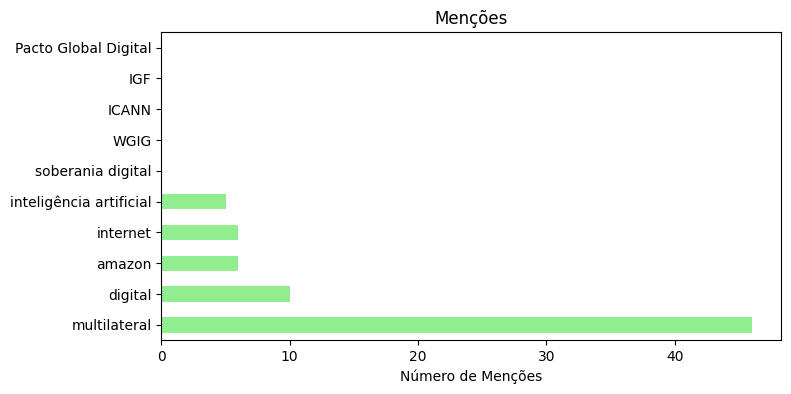

In [ ]:
termos = ['soberania digital', 'digital', 'inteligência artificial', 'internet', 'amazon', 'WGIG' , 'ICANN' , 'IGF' , 'Pacto Global Digital' , 'multilateral'  ]
frequencia = {}

for termo in termos:
    # Conta em quantos títulos a palavra aparece
    frequencia[termo] = df['texto_completo'].str.contains(termo, case=False).sum()

# Converter para série para facilitar a plotagem
ser_freq = pd.Series(frequencia)

plt.figure(figsize=(8, 4))
ser_freq.sort_values(ascending=False).plot(kind='barh', color='lightgreen')
plt.title('Menções')
plt.xlabel('Número de Menções')
plt.show()

In [ ]:
df_customizado_discursos_ministros = df_discursos_ministros[["autoria","titulo",
       "data_atualizado", "horario_atualizado", "link", "paragrafos", "texto_completo","data_dt", "hora_int", "qtd_paragrafos", "tamanho_texto"]]
df_customizado_discursos_ministros

,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto
0,carlos-alberto-franco-franca,Intervenção do senhor Ministro de Estado na ab...,21/01/2025,14h22,https://www.gov.br/mre/pt-br/centrais-de-conte...,Não posso deixar de observar a representativid...,intervenção do senhor ministro de estado na ab...,2022-10-05,0.0,0,81
1,carlos-alberto-franco-franca,Discurso do senhor Ministro de Estado para tra...,21/01/2025,14h18,https://www.gov.br/mre/pt-br/centrais-de-conte...,"Senhoras e senhores,",discurso do senhor ministro de estado para tra...,2022-11-17,0.0,0,20
2,carlos-alberto-franco-franca,Intervenção do Ministro Carlos França na Reuni...,23/06/2023,18h38,https://www.gov.br/mre/pt-br/centrais-de-conte...,"Thank you, Chair.",intervenção do ministro carlos frança na reuni...,2022-11-08,13.0,0,17
3,carlos-alberto-franco-franca,Intervenção do Ministro Carlos França na Cerim...,23/06/2023,18h38,https://www.gov.br/mre/pt-br/centrais-de-conte...,"Senhor Presidente da República,",intervenção do ministro carlos frança na cerim...,2021-05-31,11.0,0,31
4,carlos-alberto-franco-franca,Intervenção do Ministro Carlos França pela cel...,23/06/2023,18h38,https://www.gov.br/mre/pt-br/centrais-de-conte...,"Muito obrigado, Embaixador Martin Mbeng, pelas...",intervenção do ministro carlos frança pela cel...,2021-05-25,16.0,0,128
...,...,...,...,...,...,...,...,...,...,...,...
2278,mauro-vieira,Palavras do Ministro Mauro Vieira na abertura ...,08/12/2025,11h34,https://www.gov.br/mre/pt-br/centrais-de-conte...,É uma enorme satisfação para o Itamaraty unir ...,palavras do ministro mauro vieira na abertura ...,2025-12-08,9.0,0,121
2279,mauro-vieira,Discurso do Senhor Ministro de Estado por ocas...,05/12/2025,20h44,https://www.gov.br/mre/pt-br/centrais-de-conte...,"É uma alegria rever tantos rostos familiares, ...",discurso do senhor ministro de estado por ocas...,2025-12-05,19.0,0,174
2375,mauro-vieira,Brinde do Senhor Ministro de Estado por ocasiã...,18/11/2025,18h44,https://www.gov.br/mre/pt-br/centrais-de-conte...,"Senhor Secretário-Geral,",brinde do senhor ministro de estado por ocasiã...,2025-11-18,12.0,0,24
2376,mauro-vieira,Discurso do Ministro Mauro Vieira na Sessão de...,08/12/2025,11h19,https://www.gov.br/mre/pt-br/centrais-de-conte...,Senhora Secretária-Geral das Relações Exterior...,discurso do ministro mauro vieira na sessão de...,2025-11-18,10.0,0,83


def buscar_termo(termo, onde='completo'):
    """
    Busca um termo nas notas do MRE.

    Parâmetros:
        termo (str): palavra ou expressão a buscar (não diferencia maiúsc/minúsc)
        onde (str): 'titulo', 'texto' ou 'completo' (título + corpo)

    Retorna:
        DataFrame com as notas que contêm o termo
    """
    coluna = {
        'titulo': 'titulo',
        'texto': 'texto',
        'completo': 'texto_completo',
    }[onde]

    # busca case-insensitive; na=False ignora valores faltantes
    mascara = df_customizado_discursos_ministros[coluna].str.contains(termo, case=False, na=False, regex=False)
    resultado = df_customizado_discursos_ministros[mascara].sort_values('data_dt', ascending=False)

    print(f"🔎 Termo: '{termo}'  |  Onde: {onde}")
    print(f"📌 Notas encontradas: {len(resultado)} de {len(df_customizado_discursos_ministros)} ({len(resultado)/len(df_customizado_discursos_ministros)*100:.1f}%)")
    print("-" * 60)

    for _, row in resultado.iterrows():
        data_str = row['data_dt'].strftime('%d/%m/%Y') if pd.notna(row['data_dt']) else '?'
        print(f"  • [{data_str}] {row['titulo']}")

    return resultado

In [ ]:
def buscar_termo(termo, onde='completo'):
    """
    Busca um termo nas notas do MRE e salva o resultado apenas em formato Excel no Google Drive.
    Se o arquivo já existir, ele será substituído pela versão mais recente.
    """
    import os

    # Caminho de destino solicitado
    diretorio_destino = '/content/gdrive/MyDrive/Colab_Notebooks/pibic-2025-2026/resultado-busca-palavras-discursos-etc/'

    # Cria a pasta caso ela não exista
    if not os.path.exists(diretorio_destino):
        os.makedirs(diretorio_destino)

    coluna = {
        'titulo': 'titulo',
        'texto': 'texto',
        'completo': 'texto_completo',
    }[onde]

    # busca case-insensitive
    mascara = df_customizado_discursos_ministros[coluna].str.contains(termo, case=False, na=False, regex=False)
    resultado = df_customizado_discursos_ministros[mascara].sort_values('data_dt', ascending=False)

    print(f"🔎 Termo: '{termo}'  |  Onde: {onde}")
    print(f"📌 Notas encontradas: {len(resultado)}")
    print("-" * 60)

    # Salvando apenas o arquivo Excel no Google Drive
    if not resultado.empty:
        nome_base = termo.replace(' ', '_')
        caminho_excel = os.path.join(diretorio_destino, f'{nome_base}.xlsx')

        # Verifica se já existe para informar a substituição
        if os.path.exists(caminho_excel):
            print(f"🔄 O arquivo '{nome_base}.xlsx' já existia e será substituído pela versão mais recente.")

        # Exportação para Excel (sobrescreve automaticamente)
        resultado.to_excel(caminho_excel, index=False)

        print(f"✅ Arquivo Excel atualizado com sucesso no Drive:")
        print(f"   - {caminho_excel}")
    else:
        print("\n⚠️ Nenhum resultado encontrado para salvar.")

    return resultado

In [ ]:
buscar_termo('amazon', onde='completo')

🔎 Termo: 'amazon'  |  Onde: completo
📌 Notas encontradas: 0
------------------------------------------------------------

⚠️ Nenhum resultado encontrado para salvar.


,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto


In [ ]:
buscar_termo('governança', onde='completo')

🔎 Termo: 'governança'  |  Onde: completo
📌 Notas encontradas: 9
------------------------------------------------------------
🔄 O arquivo 'governança.xlsx' já existia e será substituído pela versão mais recente.
✅ Arquivo Excel atualizado com sucesso no Drive:
   - /content/gdrive/MyDrive/Colab_Notebooks/pibic-2025-2026/resultado-busca-palavras-discursos-etc/governança.xlsx


,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto
389,mauro-vieira,"Palavras do Ministro Mauro Vieira no painel ""R...",10/02/2025,17h17,https://www.gov.br/mre/pt-br/centrais-de-conte...,"Muito obrigado pelo convite, estou feliz de es...","palavras do ministro mauro vieira no painel ""r...",2025-02-10,16.0,0,276
679,mauro-vieira,Discurso do Ministro das Relações Exteriores p...,31/10/2024,17h08,https://www.gov.br/mre/pt-br/centrais-de-conte...,Este encontro representa mais uma etapa fundam...,discurso do ministro das relações exteriores p...,2024-10-31,15.0,0,481
683,mauro-vieira,Briefing do Ministro Mauro Vieira ao corpo dip...,18/10/2024,12h58,https://www.gov.br/mre/pt-br/centrais-de-conte...,Muito bom dia. Agradeço a todos pela presença ...,briefing do ministro mauro vieira ao corpo dip...,2024-10-18,11.0,0,448
694,mauro-vieira,Discurso do Ministro Mauro Vieira por ocasião ...,21/01/2025,13h32,https://www.gov.br/mre/pt-br/centrais-de-conte...,"Excelentíssimos Ministros de Relações Exteriores,",discurso do ministro mauro vieira por ocasião ...,2024-02-22,0.0,0,49
1605,carlos-alberto-franco-franca,Intervenção do Ministro Carlos França na prime...,26/06/2023,11h12,https://www.gov.br/mre/pt-br/centrais-de-conte...,"Colegas Ministros de Negócios Estrangeiros,",intervenção do ministro carlos frança na prime...,2021-06-30,17.0,0,43
1604,carlos-alberto-franco-franca,Intervenção do Ministro Carlos França na prime...,26/06/2023,11h06,https://www.gov.br/mre/pt-br/centrais-de-conte...,"Colegas Ministros de Negócios Estrangeiros,",intervenção do ministro carlos frança na prime...,2021-06-29,7.0,0,43
1636,ernesto-araujo,Alocução no café da manhã sobre o ingresso do...,25/03/2025,10h40,https://www.gov.br/mre/pt-br/centrais-de-conte...,Bom dia a todos. Muito bem-vindos ao Itamaraty...,alocução no café da manhã sobre o ingresso do...,2020-02-13,0.0,0,2147
1624,ernesto-araujo,Alocução da mesa-redonda “Perspectivas do cen...,26/03/2025,16h14,https://www.gov.br/mre/pt-br/centrais-de-conte...,O Brasil que o Presidente Bolsonaro e sua equi...,alocução da mesa-redonda “perspectivas do cen...,2019-10-28,0.0,0,1247
1850,mauro-vieira-2015-2016,Discurso do Ministro Mauro Vieira por ocasião ...,26/06/2023,17h41,https://www.gov.br/mre/pt-br/centrais-de-conte...,"Senhores Embaixadores,Saúdo e dou as boas-vind...",discurso do ministro mauro vieira por ocasião ...,2015-04-27,13.0,0,4114


In [ ]:
buscar_termo('governança global digital', onde='completo')

🔎 Termo: 'governança global digital'  |  Onde: completo
📌 Notas encontradas: 0
------------------------------------------------------------

⚠️ Nenhum resultado encontrado para salvar.


,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto


In [ ]:
buscar_termo('governança da internet', onde='completo')

🔎 Termo: 'governança da internet'  |  Onde: completo
📌 Notas encontradas: 0
------------------------------------------------------------

⚠️ Nenhum resultado encontrado para salvar.


,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto


In [ ]:
buscar_termo('governança global da internet', onde='completo')

🔎 Termo: 'governança global da internet'  |  Onde: completo
📌 Notas encontradas: 0
------------------------------------------------------------

⚠️ Nenhum resultado encontrado para salvar.


,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto


In [ ]:
buscar_termo('internet', onde='completo')

🔎 Termo: 'internet'  |  Onde: completo
📌 Notas encontradas: 0
------------------------------------------------------------

⚠️ Nenhum resultado encontrado para salvar.


,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto


In [ ]:
buscar_termo('governança global da inteligência artificial', onde='completo')

🔎 Termo: 'governança global da inteligência artificial'  |  Onde: completo
📌 Notas encontradas: 0
------------------------------------------------------------

⚠️ Nenhum resultado encontrado para salvar.


,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto


In [ ]:
buscar_termo('inteligência artificial', onde='completo')

🔎 Termo: 'inteligência artificial'  |  Onde: completo
📌 Notas encontradas: 2
------------------------------------------------------------
🔄 O arquivo 'inteligência_artificial.xlsx' já existia e será substituído pela versão mais recente.
✅ Arquivo Excel atualizado com sucesso no Drive:
   - /content/gdrive/MyDrive/Colab_Notebooks/pibic-2025-2026/resultado-busca-palavras-discursos-etc/inteligência_artificial.xlsx


,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto
389,mauro-vieira,"Palavras do Ministro Mauro Vieira no painel ""R...",10/02/2025,17h17,https://www.gov.br/mre/pt-br/centrais-de-conte...,"Muito obrigado pelo convite, estou feliz de es...","palavras do ministro mauro vieira no painel ""r...",2025-02-10,16.0,0,276
270,mauro-vieira,Abertura do seminário “Inteligência Artificial...,29/01/2025,13h38,https://www.gov.br/mre/pt-br/centrais-de-conte...,Eu queria começar agradecendo ao Tribunal de C...,abertura do seminário “inteligência artificial...,2025-01-29,13.0,0,191


### Palavras mais frequentes

Top 20 palavras nos TÍTULOS:
  ministro                  329
  discurso                  211
  mauro                     184
  vieira                    184
  ocasião                   121
  reunião                   116
  brasília                  111
  relações                  97
  exteriores                89
  intervenção               81
  abertura                  51
  estado                    49
  brasil                    47
  conselho                  47
  ernesto                   46
  araújo                    45
  senhor                    39
  sessão                    39
  ministerial               36
  ministros                 35


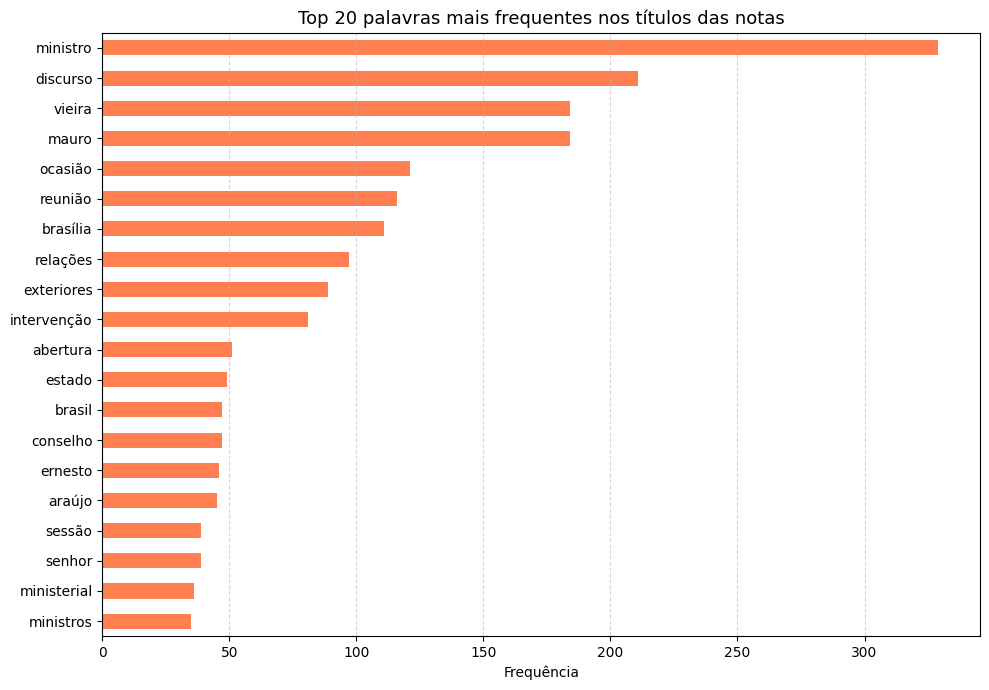

In [ ]:
import re
from collections import Counter

# Stopwords em português (lista pequena, suficiente para começar)
STOPWORDS_PT = {
    'a', 'o', 'as', 'os', 'um', 'uma', 'uns', 'umas',
    'de', 'do', 'da', 'dos', 'das', 'em', 'no', 'na', 'nos', 'nas',
    'e', 'ou', 'mas', 'que', 'se', 'por', 'para', 'com', 'sem',
    'à', 'ao', 'às', 'aos', 'pelo', 'pela', 'pelos', 'pelas',
    'é', 'são', 'foi', 'ser', 'estar', 'tem', 'ter', 'há',
    'sobre', 'entre', 'até', 'após', 'pela', 'pelo',
    'sua', 'seu', 'suas', 'seus', 'este', 'esta', 'isso', 'esse', 'essa',
    'nº', 'n°', 'nota', 'notas', 'imprensa',  # específicas do contexto
}


def palavras_mais_frequentes(serie_texto, top_n=20, min_tamanho=4):
    """Conta as palavras mais frequentes em uma coluna de texto."""
    todas_palavras = []
    for texto in serie_texto.dropna():
        # \w+ pega sequências de letras/números; flags re.UNICODE pra acentos
        palavras = re.findall(r'\b[a-záàâãéêíóôõúüç]+\b', texto.lower(), flags=re.UNICODE)
        palavras = [p for p in palavras if p not in STOPWORDS_PT and len(p) >= min_tamanho]
        todas_palavras.extend(palavras)
    return Counter(todas_palavras).most_common(top_n)


top_palavras = palavras_mais_frequentes(df_customizado_discursos_ministros['titulo'], top_n=20)
print("Top 20 palavras nos TÍTULOS:")
for palavra, contagem in top_palavras:
    print(f"  {palavra:25s} {contagem}")

# Gráfico
serie = pd.Series(dict(top_palavras)).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
serie.plot(kind='barh', ax=ax, color='coral')
ax.set_title('Top 20 palavras mais frequentes nos títulos das notas', fontsize=13)
ax.set_xlabel('Frequência')
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Nuvem de palavras

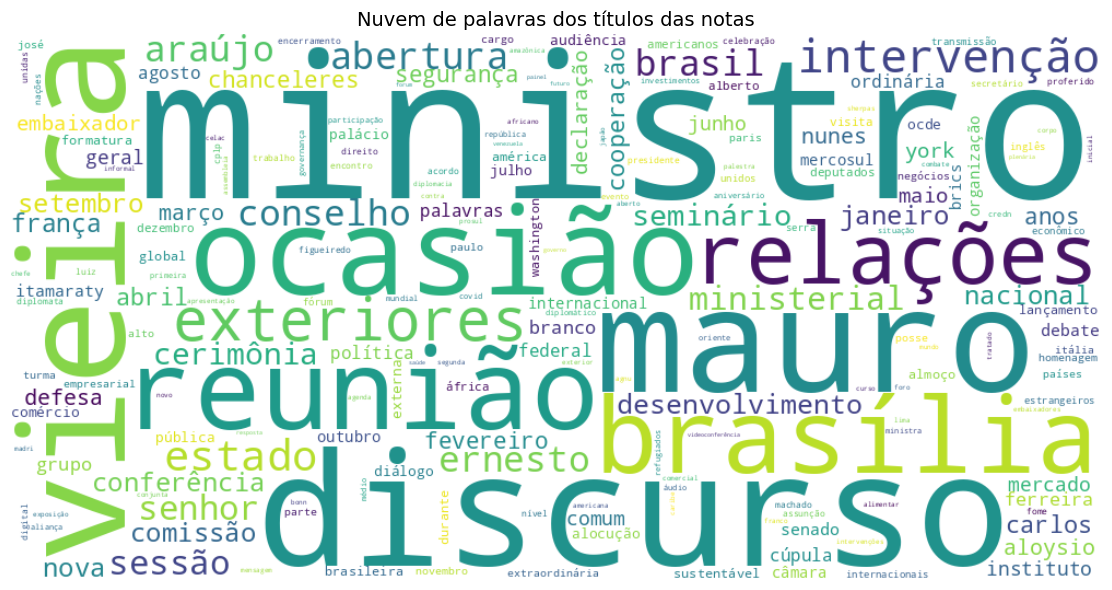

In [ ]:
from wordcloud import WordCloud

# Junta todos os títulos em um único texto gigante
texto_titulos = ' '.join(df_customizado_discursos_ministros['titulo'].dropna()).lower()

# Remove stopwords usando o set já definido
wc = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    stopwords=STOPWORDS_PT,
    colormap='viridis',
    min_word_length=4,
    collocations=False,  # evita repetir bigramas
).generate(texto_titulos)

fig, ax = plt.subplots(figsize=(13, 6))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Nuvem de palavras dos títulos das notas', fontsize=14)
plt.tight_layout()
plt.show()

### Co-ocorrência entre palavras

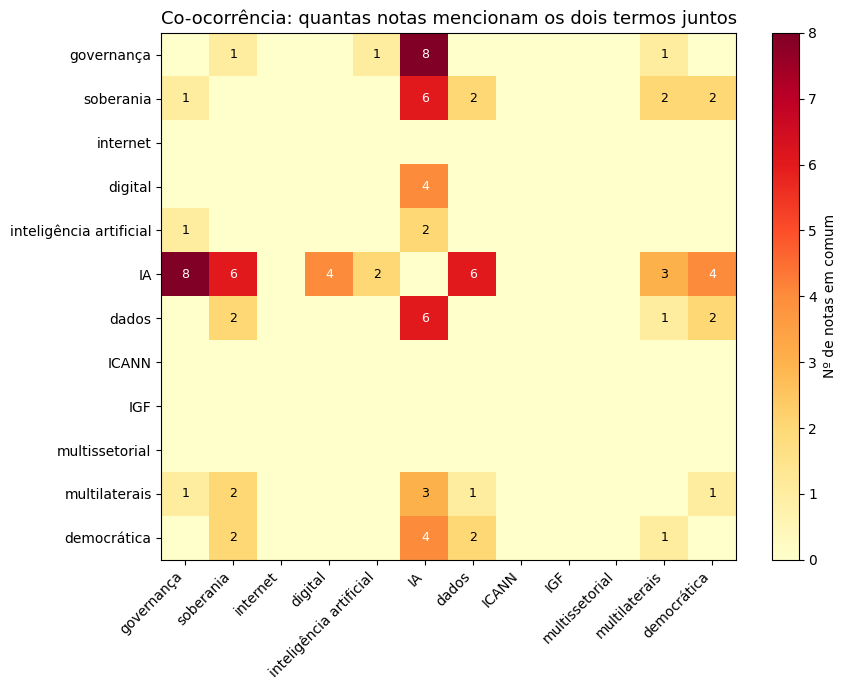

In [ ]:
import numpy as np

palavras_analise = ['governança', 'soberania' , 'internet' , 'digital' , 'inteligência artificial' , 'IA' , 'dados' , 'ICANN' , 'IGF','multissetorial','multilaterais','democrática']

# Para cada nota, marca quais países são mencionados
matriz_presenca = pd.DataFrame({
    palavra: df_discursos_ministros['texto_completo'].str.contains(palavra, case=False, na=False, regex=False).astype(int)
    for palavra in palavras_analise
})

# Matriz de co-ocorrência (multiplicação matricial: notas onde A E B aparecem)
coocorrencia = matriz_presenca.T.dot(matriz_presenca)

# Zerar a diagonal (não interessa um país com ele mesmo)
np.fill_diagonal(coocorrencia.values, 0)

# Heatmap simples com matplotlib
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(coocorrencia, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(palavras_analise)))
ax.set_yticks(range(len(palavras_analise)))
ax.set_xticklabels(palavras_analise, rotation=45, ha='right')
ax.set_yticklabels(palavras_analise)
ax.set_title('Co-ocorrência: quantas notas mencionam os dois termos juntos', fontsize=13)

# Anotar os valores nas células
for i in range(len(palavras_analise)):
    for j in range(len(palavras_analise)):
        valor = coocorrencia.iloc[i, j]
        if valor > 0:
            ax.text(j, i, int(valor), ha='center', va='center',
                    color='black' if valor < coocorrencia.values.max()/2 else 'white',
                    fontsize=9)

plt.colorbar(im, ax=ax, label='Nº de notas em comum')
plt.tight_layout()
plt.show()

multissetorial

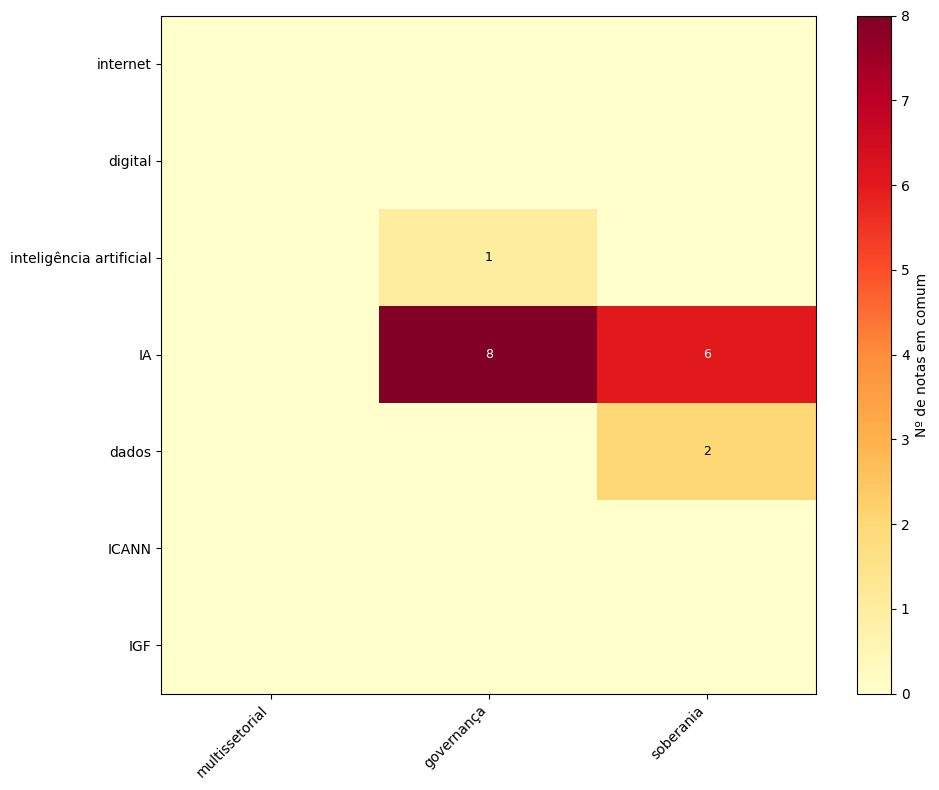

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Definir as palavras para os eixos vertical e horizontal
palavras_vertical = ['internet', 'digital', 'inteligência artificial', 'IA', 'dados', 'ICANN', 'IGF']
palavras_horizontal = ['multissetorial', 'governança', 'soberania']

# Combinar todas as palavras para criar a matriz de presença inicial
palavras_analise_total = list(set(palavras_vertical + palavras_horizontal))

# Para cada nota, marca quais palavras são mencionadas
matriz_presenca = pd.DataFrame({
    palavra: df_discursos_ministros['texto_completo'].str.contains(palavra, case=False, na=False, regex=False).astype(int)
    for palavra in palavras_analise_total
})

# Matriz de co-ocorrência entre os dois conjuntos de palavras
# Linhas: palavras_vertical, Colunas: palavras_horizontal
coocorrencia_personalizada = matriz_presenca[palavras_vertical].T.dot(matriz_presenca[palavras_horizontal])

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(coocorrencia_personalizada, cmap='YlOrRd', aspect='auto')

# Configurar os rótulos dos eixos
ax.set_xticks(range(len(palavras_horizontal)))
ax.set_yticks(range(len(palavras_vertical)))
ax.set_xticklabels(palavras_horizontal, rotation=45, ha='right')
ax.set_yticklabels(palavras_vertical)

# Anotar os valores nas células
for i in range(len(palavras_vertical)):
    for j in range(len(palavras_horizontal)):
        valor = coocorrencia_personalizada.iloc[i, j]
        if valor > 0:
            ax.text(j, i, int(valor), ha='center', va='center',
                    color='black' if valor < coocorrencia_personalizada.values.max()/2 else 'white',
                    fontsize=9)

plt.colorbar(im, ax=ax, label='Nº de notas em comum')
plt.tight_layout()
plt.show()

multilateral

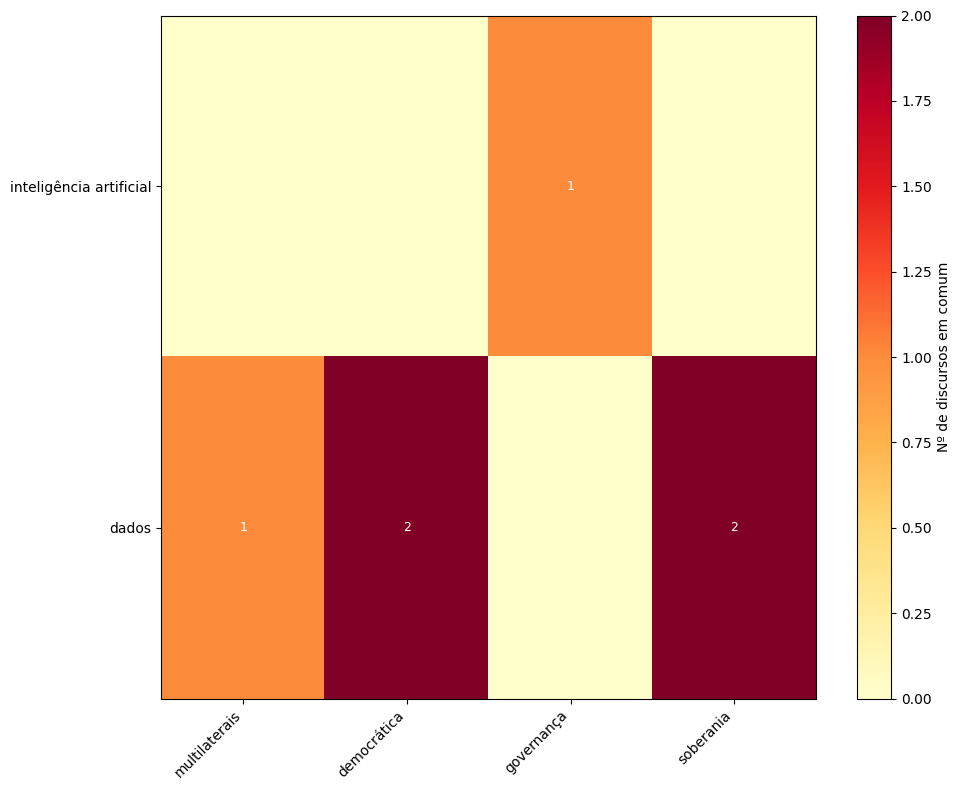

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Definir as palavras para os eixos vertical e horizontal
palavras_vertical = ['inteligência artificial', 'dados']
palavras_horizontal = ['multilaterais','democrática', 'governança', 'soberania']

# Combinar todas as palavras para criar a matriz de presença inicial
palavras_analise_total = list(set(palavras_vertical + palavras_horizontal))

# Para cada nota, marca quais palavras são mencionadas
matriz_presenca = pd.DataFrame({
    palavra: df_discursos_ministros['texto_completo'].str.contains(palavra, case=False, na=False, regex=False).astype(int)
    for palavra in palavras_analise_total
})

# Matriz de co-ocorrência entre os dois conjuntos de palavras
# Linhas: palavras_vertical, Colunas: palavras_horizontal
coocorrencia_personalizada = matriz_presenca[palavras_vertical].T.dot(matriz_presenca[palavras_horizontal])

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(coocorrencia_personalizada, cmap='YlOrRd', aspect='auto')

# Configurar os rótulos dos eixos
ax.set_xticks(range(len(palavras_horizontal)))
ax.set_yticks(range(len(palavras_vertical)))
ax.set_xticklabels(palavras_horizontal, rotation=45, ha='right')
ax.set_yticklabels(palavras_vertical)

# Anotar os valores nas células
for i in range(len(palavras_vertical)):
    for j in range(len(palavras_horizontal)):
        valor = coocorrencia_personalizada.iloc[i, j]
        if valor > 0:
            ax.text(j, i, int(valor), ha='center', va='center',
                    color='black' if valor < coocorrencia_personalizada.values.max()/2 else 'white',
                    fontsize=9)

plt.colorbar(im, ax=ax, label='Nº de discursos em comum')
plt.tight_layout()
plt.show()

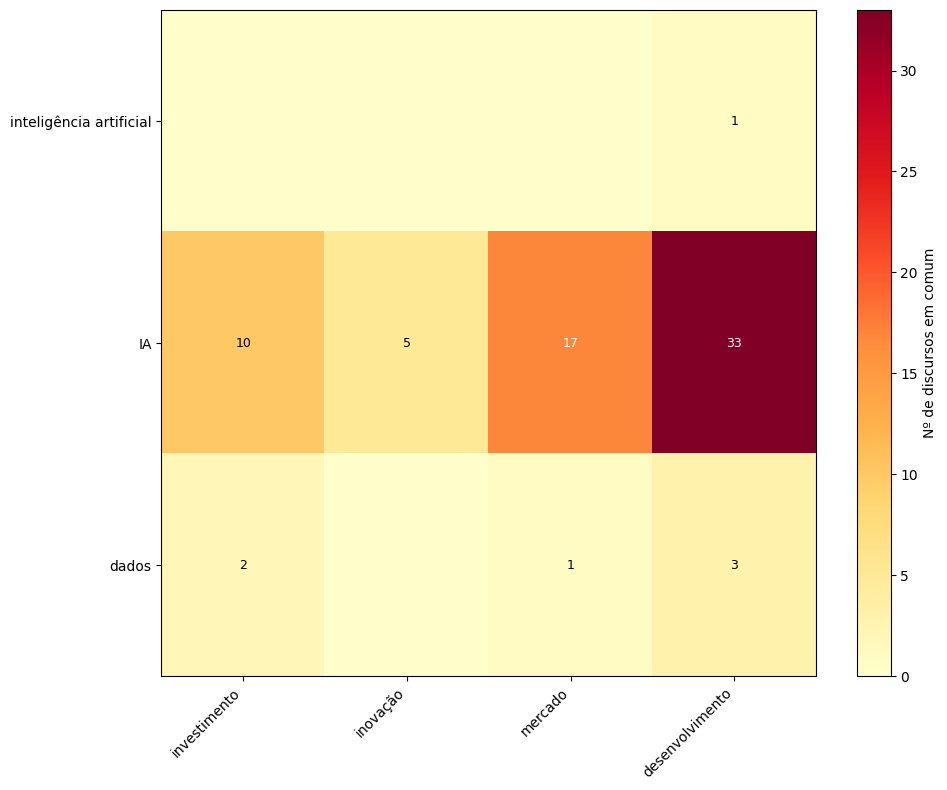

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Definir as palavras para os eixos vertical e horizontal
palavras_vertical = ['inteligência artificial', 'IA', 'dados']
palavras_horizontal = ["investimento", "inovação", "mercado", "desenvolvimento"]

# Combinar todas as palavras para criar a matriz de presença inicial
palavras_analise_total = list(set(palavras_vertical + palavras_horizontal))

# Para cada nota, marca quais palavras são mencionadas
matriz_presenca = pd.DataFrame({
    palavra: df_discursos_ministros['texto_completo'].str.contains(palavra, case=False, na=False, regex=False).astype(int)
    for palavra in palavras_analise_total
})

# Matriz de co-ocorrência entre os dois conjuntos de palavras
# Linhas: palavras_vertical, Colunas: palavras_horizontal
coocorrencia_personalizada = matriz_presenca[palavras_vertical].T.dot(matriz_presenca[palavras_horizontal])

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(coocorrencia_personalizada, cmap='YlOrRd', aspect='auto')

# Configurar os rótulos dos eixos
ax.set_xticks(range(len(palavras_horizontal)))
ax.set_yticks(range(len(palavras_vertical)))
ax.set_xticklabels(palavras_horizontal, rotation=45, ha='right')
ax.set_yticklabels(palavras_vertical)

# Anotar os valores nas células
for i in range(len(palavras_vertical)):
    for j in range(len(palavras_horizontal)):
        valor = coocorrencia_personalizada.iloc[i, j]
        if valor > 0:
            ax.text(j, i, int(valor), ha='center', va='center',
                    color='black' if valor < coocorrencia_personalizada.values.max()/2 else 'white',
                    fontsize=9)

plt.colorbar(im, ax=ax, label='Nº de discursos em comum')
plt.tight_layout()
plt.show()

## Secretaria-geral

In [ ]:
secretaria = ['maria-laura-da-rocha-2023' , 'fernando-simas-magalhaes' , 'otavio-brandelli-2019-2021' , 'marcos-bezerra-abbott-galvao-2016-2018' , 'sergio-franca-danese-2015-2016' , 'eduardo-dos-santos-2013-2015']
pattern = '|'.join(secretaria)
df_discursos_secretaria = df_discursos[(df_discursos['extra_01'].astype(str).str.contains('secretario-geral')) & (df_discursos['autoria'].astype(str).str.contains(pattern))]
df_discursos_secretaria

,tipo_dado,pais,origem,sigla,classificado,categoria,autoria,titulo,subtitulo,data,...,extra_02,extra_03,data_dt,texto,texto_completo,hora_int,ano_mes,dia_semana,tamanho_texto,qtd_paragrafos
172,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,maria-laura-da-rocha-2023,"Discurso da senhora ministra de Estado, substi...",NA,10/09/2024,...,NA,NA,2024-09-10,"Senhoras e senhores, bem-vindas e bem-vindos a...","discurso da senhora ministra de estado, substi...",12.0,2024-09,Tuesday,317,0
179,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,maria-laura-da-rocha-2023,Intervenção da Senhora Secretária-Geral das Re...,NA,26/06/2024,...,NA,NA,2024-06-26,"Antes de mais nada, em nome do governo brasile...",intervenção da senhora secretária-geral das re...,10.0,2024-06,Wednesday,438,0
180,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,maria-laura-da-rocha-2023,"Discurso da Ministra, substituta, das Relações...","Brasília, 13/06/2024",13/06/2024,...,NA,NA,2024-06-13,"Senhoras e senhores,","discurso da ministra, substituta, das relações...",21.0,2024-06,Thursday,20,0
187,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,maria-laura-da-rocha-2023,Intervenção da Senhora Secretária-Geral das Re...,"Brasília, 28 de maio de 2024",28/05/2024,...,NA,NA,2024-05-28,Senhora Presidente do Conselho de Curadores da...,intervenção da senhora secretária-geral das re...,18.0,2024-05,Tuesday,81,0
188,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,maria-laura-da-rocha-2023,"Discurso da Secretária-Geral, Embaixadora Mari...","Brasília, 28 de maio de 2024",28/05/2024,...,NA,NA,2024-05-28,"Ao encerrarmos o seminário ""Encontros - 200 an...","discurso da secretária-geral, embaixadora mari...",17.0,2024-05,Tuesday,407,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2044,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,eduardo-dos-santos-2013-2015,Discurso do Secretário-Geral Eduardo dos Santo...,"Rio de Janeiro, 8 de abril de 2014",08/04/2014,...,NA,NA,2014-04-08,Foi com grande satisfação que aceitei o convit...,discurso do secretário-geral eduardo dos santo...,0.0,2014-04,Tuesday,544,0
2162,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,maria-laura-da-rocha-2023,"Discurso da Ministra, substituta, das Relações...",NA,30/07/2025,...,NA,NA,2025-07-30,Senhoras e Senhores,"discurso da ministra, substituta, das relações...",12.0,2025-07,Wednesday,19,0
2163,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,maria-laura-da-rocha-2023,"Discurso da Ministra, substituta, das Relações...",NA,29/07/2025,...,NA,NA,2025-07-29,Senhoras e Senhores,"discurso da ministra, substituta, das relações...",10.0,2025-07,Tuesday,19,0
2164,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,discursos,maria-laura-da-rocha-2023,Discurso da Secretária-Geral em ato solene por...,NA,16/07/2025,...,NA,NA,2025-07-16,"Senhoras e Senhores,",discurso da secretária-geral em ato solene por...,14.0,2025-07,Wednesday,20,0


In [ ]:
# Extrair apenas o ano
df_discursos_secretaria["ano"] = df_discursos_secretaria["data_dt"].dt.year

discursos_por_ano_secretaria = df_discursos_secretaria['ano'].value_counts().sort_index()

display(discursos_por_ano_secretaria)

/tmp/ipykernel_597/2691109334.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_discursos_secretaria["ano"] = df_discursos_secretaria["data_dt"].dt.year


,count
ano,
2014,4
2015,24
2016,7
2017,2
2018,2
2019,2
2021,1
2023,11
2024,16


### Análise de palavras chave

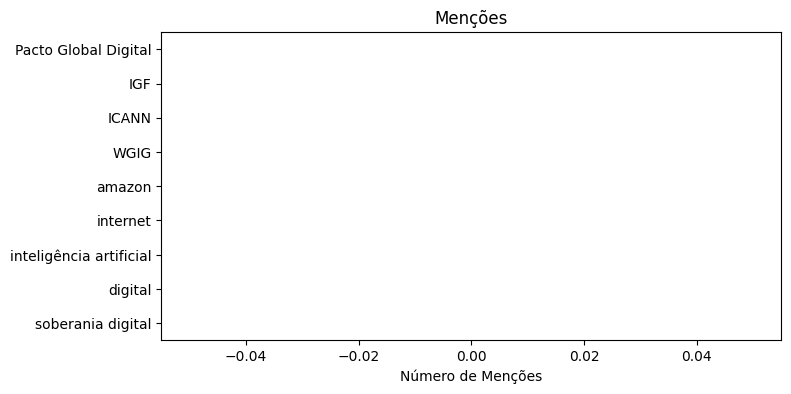

In [ ]:
termos = ['soberania digital', 'digital', 'inteligência artificial', 'internet', 'amazon', 'WGIG' , 'ICANN' , 'IGF' , 'Pacto Global Digital']
frequencia = {}

for termo in termos:
    # Conta em quantos títulos a palavra aparece
    frequencia[termo] = df_discursos_secretaria['texto_completo'].str.contains(termo, case=False).sum()

# Converter para série para facilitar a plotagem
ser_freq = pd.Series(frequencia)

plt.figure(figsize=(8, 4))
ser_freq.sort_values(ascending=False).plot(kind='barh', color='lightgreen')
plt.title('Menções')
plt.xlabel('Número de Menções')
plt.show()

### palavras mais frequentes

### Nuvem de palavras

### Co-ocorrência de palavras

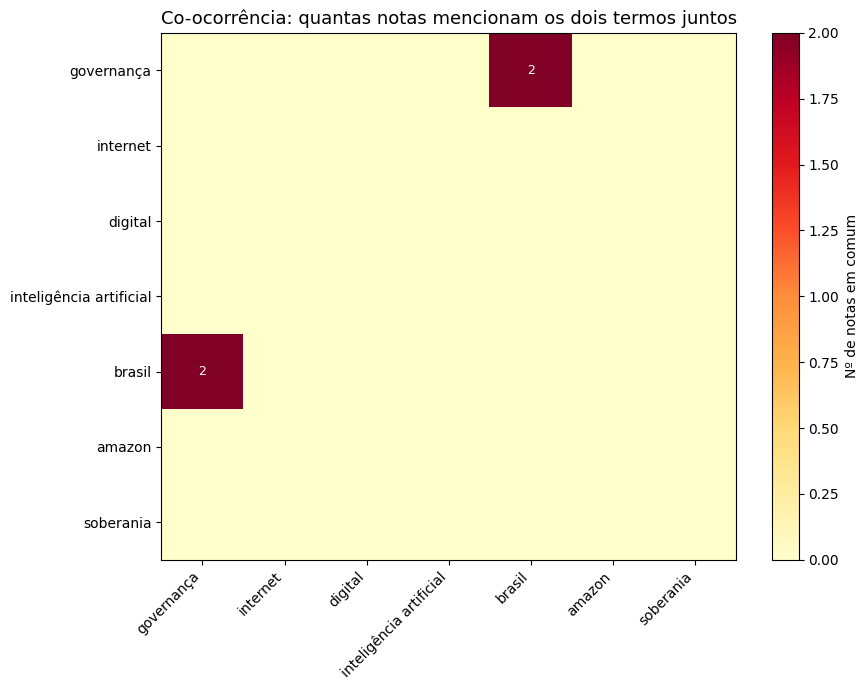

In [ ]:
import numpy as np

palavras_analise = ['governança', 'internet' , 'digital' , 'inteligência artificial', 'brasil', 'amazon', 'soberania']

# Para cada nota, marca quais países são mencionados
matriz_presenca = pd.DataFrame({
    palavra: df_discursos_secretaria['texto_completo'].str.contains(palavra, case=False, na=False, regex=False).astype(int)
    for palavra in palavras_analise
})

# Matriz de co-ocorrência (multiplicação matricial: notas onde A E B aparecem)
coocorrencia = matriz_presenca.T.dot(matriz_presenca)

# Zerar a diagonal (não interessa um país com ele mesmo)
np.fill_diagonal(coocorrencia.values, 0)

# Heatmap simples com matplotlib
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(coocorrencia, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(palavras_analise)))
ax.set_yticks(range(len(palavras_analise)))
ax.set_xticklabels(palavras_analise, rotation=45, ha='right')
ax.set_yticklabels(palavras_analise)
ax.set_title('Co-ocorrência: quantas notas mencionam os dois termos juntos', fontsize=13)

# Anotar os valores nas células
for i in range(len(palavras_analise)):
    for j in range(len(palavras_analise)):
        valor = coocorrencia.iloc[i, j]
        if valor > 0:
            ax.text(j, i, int(valor), ha='center', va='center',
                    color='black' if valor < coocorrencia.values.max()/2 else 'white',
                    fontsize=9)

plt.colorbar(im, ax=ax, label='Nº de notas em comum')
plt.tight_layout()
plt.show()

multissetorial


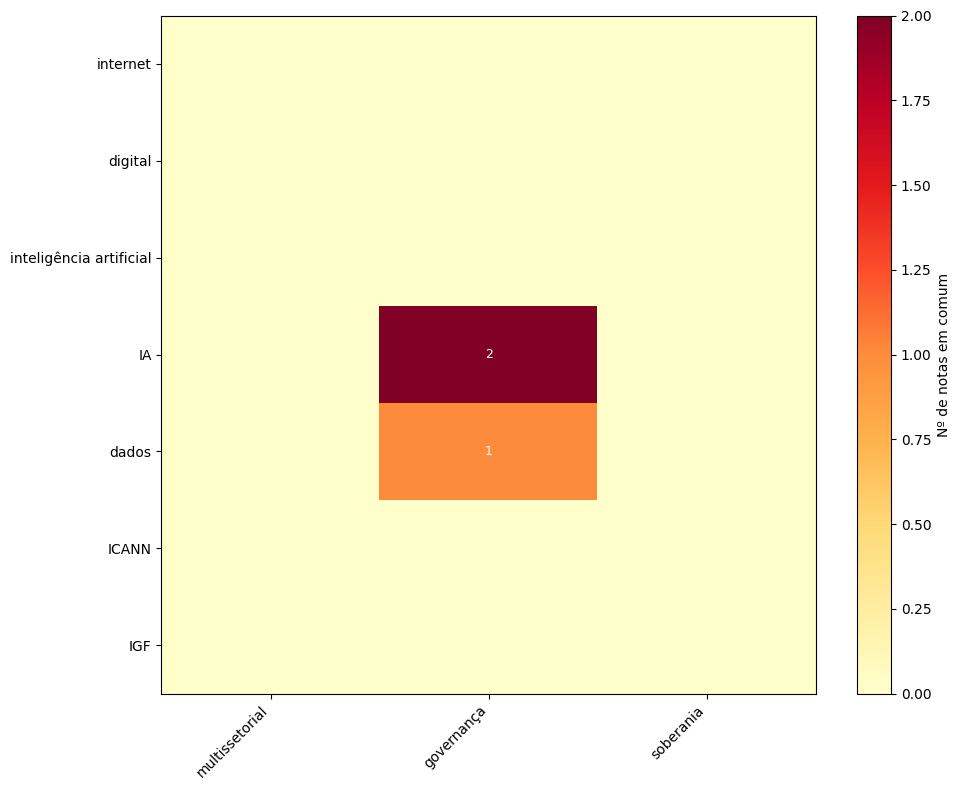

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Definir as palavras para os eixos vertical e horizontal
palavras_vertical = ['internet', 'digital', 'inteligência artificial', 'IA', 'dados', 'ICANN', 'IGF']
palavras_horizontal = ['multissetorial', 'governança', 'soberania']

# Combinar todas as palavras para criar a matriz de presença inicial
palavras_analise_total = list(set(palavras_vertical + palavras_horizontal))

# Para cada nota, marca quais palavras são mencionadas
matriz_presenca = pd.DataFrame({
    palavra: df_discursos_secretaria['texto_completo'].str.contains(palavra, case=False, na=False, regex=False).astype(int)
    for palavra in palavras_analise_total
})

# Matriz de co-ocorrência entre os dois conjuntos de palavras
# Linhas: palavras_vertical, Colunas: palavras_horizontal
coocorrencia_personalizada = matriz_presenca[palavras_vertical].T.dot(matriz_presenca[palavras_horizontal])

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(coocorrencia_personalizada, cmap='YlOrRd', aspect='auto')

# Configurar os rótulos dos eixos
ax.set_xticks(range(len(palavras_horizontal)))
ax.set_yticks(range(len(palavras_vertical)))
ax.set_xticklabels(palavras_horizontal, rotation=45, ha='right')
ax.set_yticklabels(palavras_vertical)

# Anotar os valores nas células
for i in range(len(palavras_vertical)):
    for j in range(len(palavras_horizontal)):
        valor = coocorrencia_personalizada.iloc[i, j]
        if valor > 0:
            ax.text(j, i, int(valor), ha='center', va='center',
                    color='black' if valor < coocorrencia_personalizada.values.max()/2 else 'white',
                    fontsize=9)

plt.colorbar(im, ax=ax, label='Nº de notas em comum')
plt.tight_layout()
plt.show()

multilateral

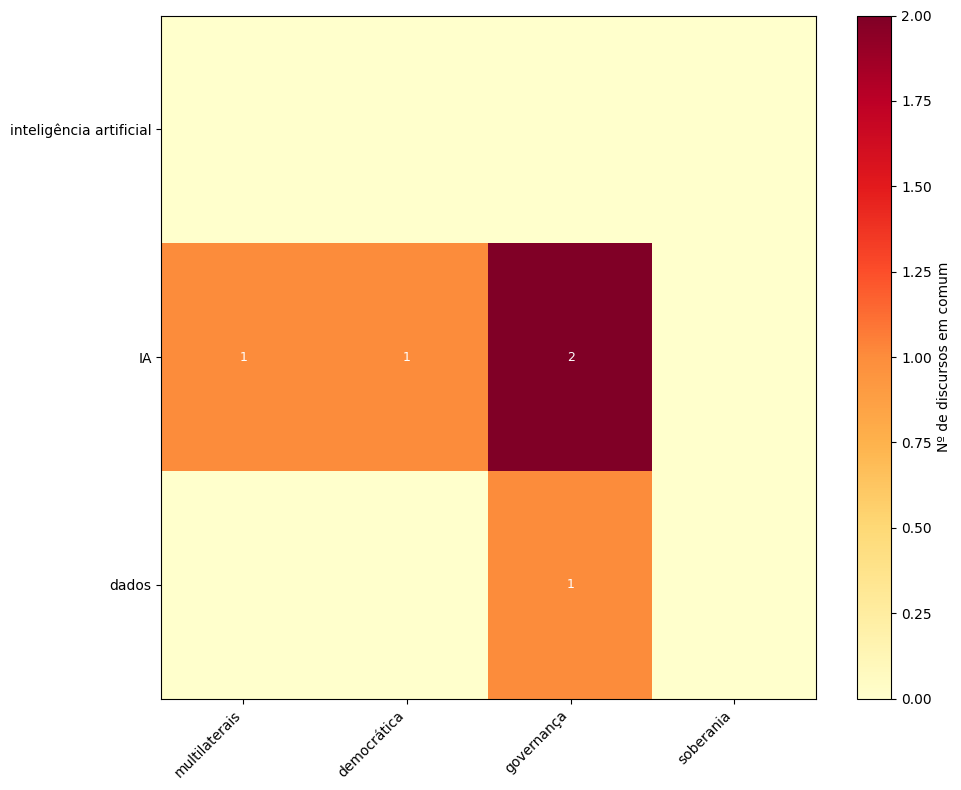

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Definir as palavras para os eixos vertical e horizontal
palavras_vertical = ['inteligência artificial', 'IA', 'dados']
palavras_horizontal = ['multilaterais','democrática', 'governança', 'soberania']

# Combinar todas as palavras para criar a matriz de presença inicial
palavras_analise_total = list(set(palavras_vertical + palavras_horizontal))

# Para cada nota, marca quais palavras são mencionadas
matriz_presenca = pd.DataFrame({
    palavra: df_discursos_secretaria['texto_completo'].str.contains(palavra, case=False, na=False, regex=False).astype(int)
    for palavra in palavras_analise_total
})

# Matriz de co-ocorrência entre os dois conjuntos de palavras
# Linhas: palavras_vertical, Colunas: palavras_horizontal
coocorrencia_personalizada = matriz_presenca[palavras_vertical].T.dot(matriz_presenca[palavras_horizontal])

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(coocorrencia_personalizada, cmap='YlOrRd', aspect='auto')

# Configurar os rótulos dos eixos
ax.set_xticks(range(len(palavras_horizontal)))
ax.set_yticks(range(len(palavras_vertical)))
ax.set_xticklabels(palavras_horizontal, rotation=45, ha='right')
ax.set_yticklabels(palavras_vertical)

# Anotar os valores nas células
for i in range(len(palavras_vertical)):
    for j in range(len(palavras_horizontal)):
        valor = coocorrencia_personalizada.iloc[i, j]
        if valor > 0:
            ax.text(j, i, int(valor), ha='center', va='center',
                    color='black' if valor < coocorrencia_personalizada.values.max()/2 else 'white',
                    fontsize=9)

plt.colorbar(im, ax=ax, label='Nº de discursos em comum')
plt.tight_layout()
plt.show()

# Artigos

## Ministros

In [ ]:
ministros = ['mauro-vieira' , 'carlos-alberto-franco-franca' , 'ernesto-araujo' , 'aloysio-nunes-ferreira' , 'jose-serra' , 'mauro-vieira-2015-2016' , 'luis-alberto-figueiredo-machado']
pattern = '|'.join(ministros)
df_artigos_ministros = df_artigos[(df_artigos['extra_01'].astype(str).str.contains('ministro-das-relacoes-exteriores')) & (df_artigos['autoria'].astype(str).str.contains(pattern))]
df_artigos_ministros

,tipo_dado,pais,origem,sigla,classificado,categoria,autoria,titulo,subtitulo,data,...,extra_02,extra_03,data_dt,texto,texto_completo,hora_int,ano_mes,dia_semana,tamanho_texto,qtd_paragrafos
1383,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,artigos,mauro-vieira-2023,Brasil amplia rede de acordos e reforça inserç...,NA,29/09/2025,...,NA,NA,2025-09-29,Vice-presidente da República e ministro do Des...,brasil amplia rede de acordos e reforça inserç...,0.0,2025-09,Monday,90,0
1384,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,artigos,mauro-vieira-2023,Opinião: Diplomacia em defesa da soberania (O ...,Quando os Estados Unidos indicarem disposição ...,17/09/2025,...,NA,NA,2025-09-17,Diplomacia é o ofício do diálogo e da negociaç...,opinião: diplomacia em defesa da soberania (o ...,17.0,2025-09,Wednesday,170,0
1397,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,artigos,mauro-vieira-2023,Brasil e Portugal: uma amizade bicentenária (P...,NA,29/08/2025,...,NA,NA,2025-08-29,"Hoje, 29 de agosto de 2025, celebramos o bicen...",brasil e portugal: uma amizade bicentenária (p...,10.0,2025-08,Friday,486,0
1421,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,artigos,mauro-vieira-2023,"BRICS, diplomacia criativa para um mundo em cr...",Defesa da diplomacia e do multilateralismo exi...,05/06/2025,...,NA,NA,2025-06-05,Mauro Vieira,"brics, diplomacia criativa para um mundo em cr...",0.0,2025-06,Thursday,12,0
1431,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,artigos,mauro-vieira-2023,"Acordo Mercosul-UE é entendimento benéfico, es...",Parceria prevê condições favoráveis para a nos...,10/12/2024,...,NA,NA,2024-12-10,"Geraldo Alckmin, Mauro Vieira","acordo mercosul-ue é entendimento benéfico, es...",9.0,2024-12,Tuesday,29,0
1447,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,artigos,mauro-vieira-2023,"O Brasil voltou, para fazer a diferença (O Glo...",NA,24/11/2024,...,NA,NA,2024-11-24,"Mauro VieiraA retomada, pela política externa ...","o brasil voltou, para fazer a diferença (o glo...",9.0,2024-11,Sunday,537,0
1460,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,artigos,mauro-vieira-2023,As boas notícias que vêm da Ásia (O Globo - 6/...,NA,08/04/2024,...,NA,NA,2024-04-08,"Em 2023, o Brasil exportou US$ 2,1 bilhões par...",as boas notícias que vêm da ásia (o globo - 6/...,12.0,2024-04,Monday,106,0
1473,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,artigos,mauro-vieira-2023,"Opinião: Cessar-fogo e Palestina na ONU, neces...",NA,25/03/2024,...,NA,NA,2024-03-25,Por Mauro Vieira25/03/2024 | 03h00,"opinião: cessar-fogo e palestina na onu, neces...",3.0,2024-03,Monday,34,0
1480,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,artigos,mauro-vieira-2023,"Brasil, Gaza e o julgamento na corte internaci...",NA,22/01/2024,...,NA,NA,2024-01-22,Venho acompanhando com vivo interesse o debate...,"brasil, gaza e o julgamento na corte internaci...",10.0,2024-01,Monday,513,0
1500,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,artigos,mauro-vieira-2023,O Brasil no Conselho de Segurança e a guerra (...,NA,05/11/2023,...,NA,NA,2023-11-05,,o brasil no conselho de segurança e a guerra (...,0.0,2023-11,Sunday,0,0


In [ ]:
# Extrair apenas o ano
df_artigos_ministros["ano"] = df_artigos_ministros["data_dt"].dt.year

artigos_por_ano_ministros = df_artigos_ministros['ano'].value_counts().sort_index()

display(artigos_por_ano_ministros)

/tmp/ipykernel_597/2246022984.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_artigos_ministros["ano"] = df_artigos_ministros["data_dt"].dt.year


,count
ano,
2015,6
2016,10
2019,9
2020,1
2023,13
2024,5
2025,5


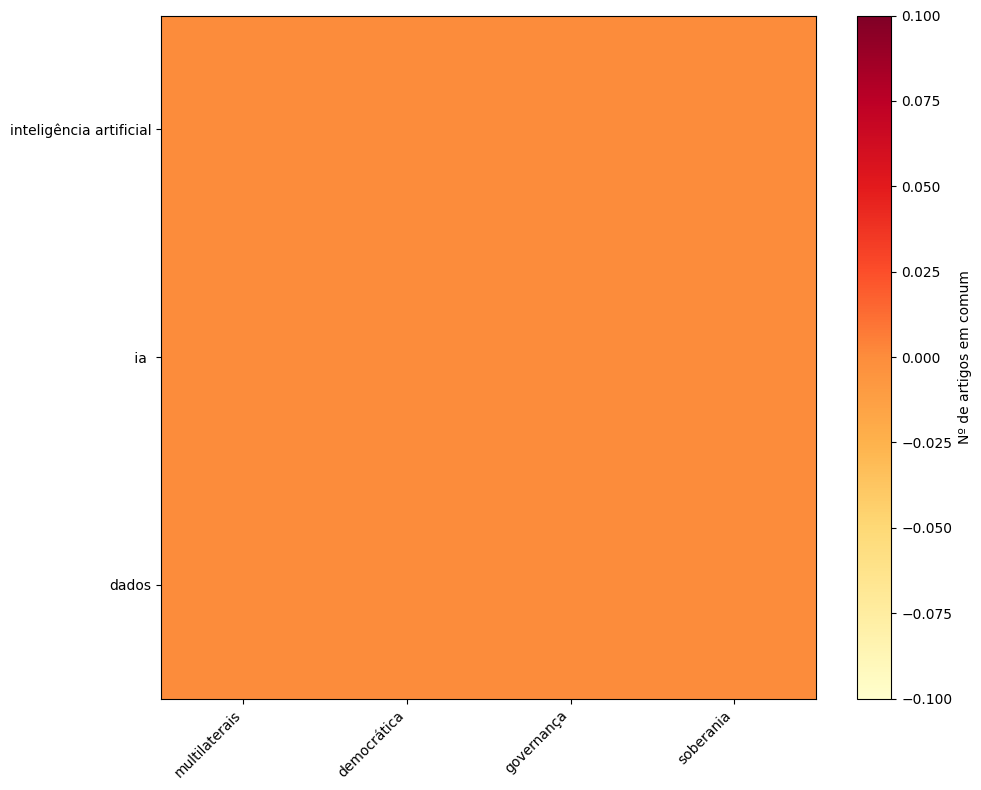

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Definir as palavras para os eixos vertical e horizontal
palavras_vertical = ['inteligência artificial', ' ia ', 'dados']
palavras_horizontal = ['multilaterais','democrática', 'governança', 'soberania']

# Combinar todas as palavras para criar a matriz de presença inicial
palavras_analise_total = list(set(palavras_vertical + palavras_horizontal))

# Para cada nota, marca quais palavras são mencionadas
matriz_presenca = pd.DataFrame({
    palavra: df_artigos_ministros['texto_completo'].str.contains(palavra, case=False, na=False, regex=False).astype(int)
    for palavra in palavras_analise_total
})

# Matriz de co-ocorrência entre os dois conjuntos de palavras
# Linhas: palavras_vertical, Colunas: palavras_horizontal
coocorrencia_personalizada = matriz_presenca[palavras_vertical].T.dot(matriz_presenca[palavras_horizontal])

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(coocorrencia_personalizada, cmap='YlOrRd', aspect='auto')

# Configurar os rótulos dos eixos
ax.set_xticks(range(len(palavras_horizontal)))
ax.set_yticks(range(len(palavras_vertical)))
ax.set_xticklabels(palavras_horizontal, rotation=45, ha='right')
ax.set_yticklabels(palavras_vertical)

# Anotar os valores nas células
for i in range(len(palavras_vertical)):
    for j in range(len(palavras_horizontal)):
        valor = coocorrencia_personalizada.iloc[i, j]
        if valor > 0:
            ax.text(j, i, int(valor), ha='center', va='center',
                    color='black' if valor < coocorrencia_personalizada.values.max()/2 else 'white',
                    fontsize=9)

plt.colorbar(im, ax=ax, label='Nº de artigos em comum')
plt.tight_layout()
plt.show()

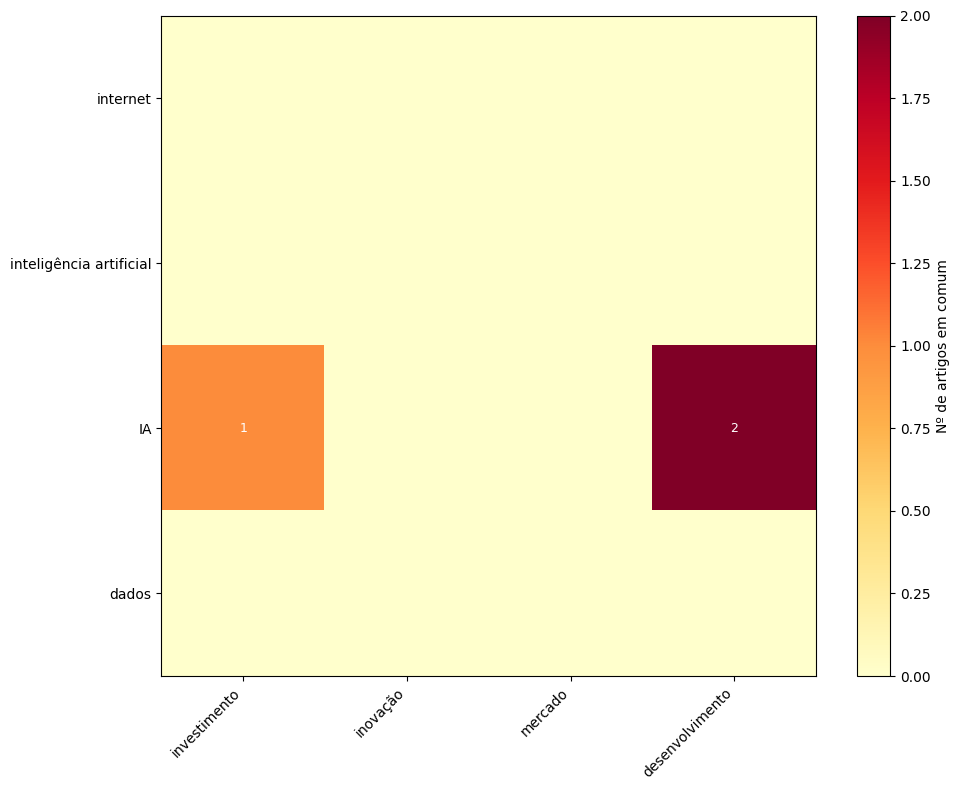

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Definir as palavras para os eixos vertical e horizontal
palavras_vertical = ['internet','inteligência artificial', 'IA', 'dados']
palavras_horizontal = ["investimento", "inovação", "mercado", "desenvolvimento"]

# Combinar todas as palavras para criar a matriz de presença inicial
palavras_analise_total = list(set(palavras_vertical + palavras_horizontal))

# Para cada nota, marca quais palavras são mencionadas
matriz_presenca = pd.DataFrame({
    palavra: df_artigos_ministros['texto_completo'].str.contains(palavra, case=False, na=False, regex=False).astype(int)
    for palavra in palavras_analise_total
})

# Matriz de co-ocorrência entre os dois conjuntos de palavras
# Linhas: palavras_vertical, Colunas: palavras_horizontal
coocorrencia_personalizada = matriz_presenca[palavras_vertical].T.dot(matriz_presenca[palavras_horizontal])

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(coocorrencia_personalizada, cmap='YlOrRd', aspect='auto')

# Configurar os rótulos dos eixos
ax.set_xticks(range(len(palavras_horizontal)))
ax.set_yticks(range(len(palavras_vertical)))
ax.set_xticklabels(palavras_horizontal, rotation=45, ha='right')
ax.set_yticklabels(palavras_vertical)

# Anotar os valores nas células
for i in range(len(palavras_vertical)):
    for j in range(len(palavras_horizontal)):
        valor = coocorrencia_personalizada.iloc[i, j]
        if valor > 0:
            ax.text(j, i, int(valor), ha='center', va='center',
                    color='black' if valor < coocorrencia_personalizada.values.max()/2 else 'white',
                    fontsize=9)

plt.colorbar(im, ax=ax, label='Nº de artigos em comum')
plt.tight_layout()
plt.show()

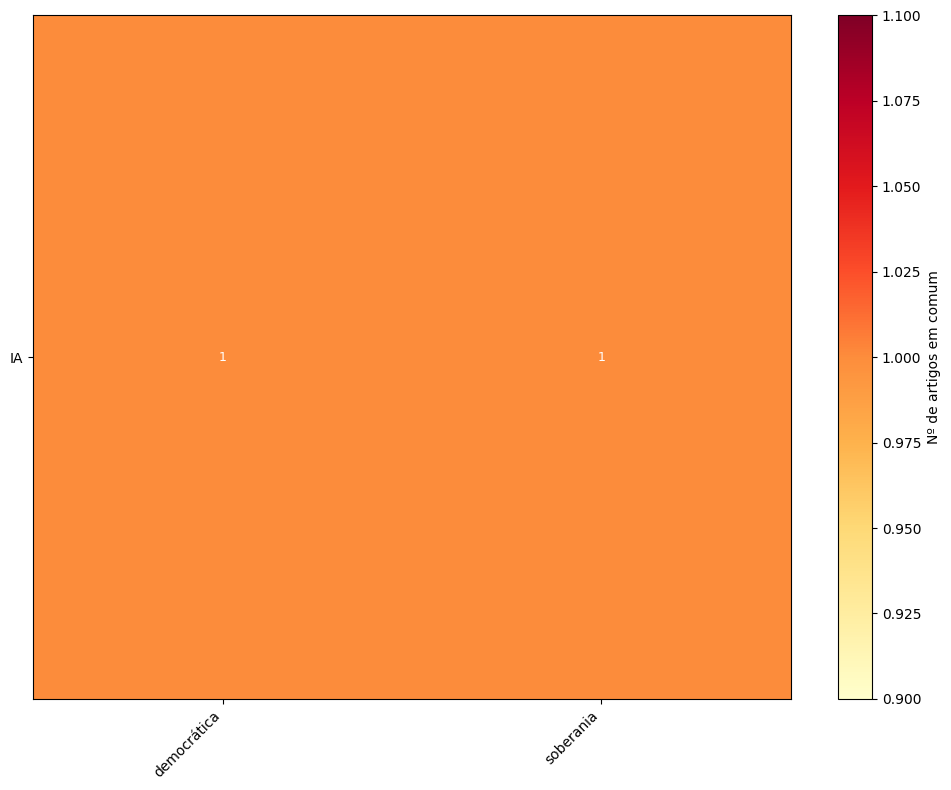

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Definir as palavras para os eixos vertical e horizontal
palavras_vertical = [ 'IA']
palavras_horizontal = ['democrática', 'soberania']

# Combinar todas as palavras para criar a matriz de presença inicial
palavras_analise_total = list(set(palavras_vertical + palavras_horizontal))

# Para cada nota, marca quais palavras são mencionadas
matriz_presenca = pd.DataFrame({
    palavra: df_artigos_ministros['texto_completo'].str.contains(palavra, case=False, na=False, regex=False).astype(int)
    for palavra in palavras_analise_total
})

# Matriz de co-ocorrência entre os dois conjuntos de palavras
# Linhas: palavras_vertical, Colunas: palavras_horizontal
coocorrencia_personalizada = matriz_presenca[palavras_vertical].T.dot(matriz_presenca[palavras_horizontal])

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(coocorrencia_personalizada, cmap='YlOrRd', aspect='auto')

# Configurar os rótulos dos eixos
ax.set_xticks(range(len(palavras_horizontal)))
ax.set_yticks(range(len(palavras_vertical)))
ax.set_xticklabels(palavras_horizontal, rotation=45, ha='right')
ax.set_yticklabels(palavras_vertical)

# Anotar os valores nas células
for i in range(len(palavras_vertical)):
    for j in range(len(palavras_horizontal)):
        valor = coocorrencia_personalizada.iloc[i, j]
        if valor > 0:
            ax.text(j, i, int(valor), ha='center', va='center',
                    color='black' if valor < coocorrencia_personalizada.values.max()/2 else 'white',
                    fontsize=9)

plt.colorbar(im, ax=ax, label='Nº de artigos em comum')
plt.tight_layout()
plt.show()

### Análise de palavras chave

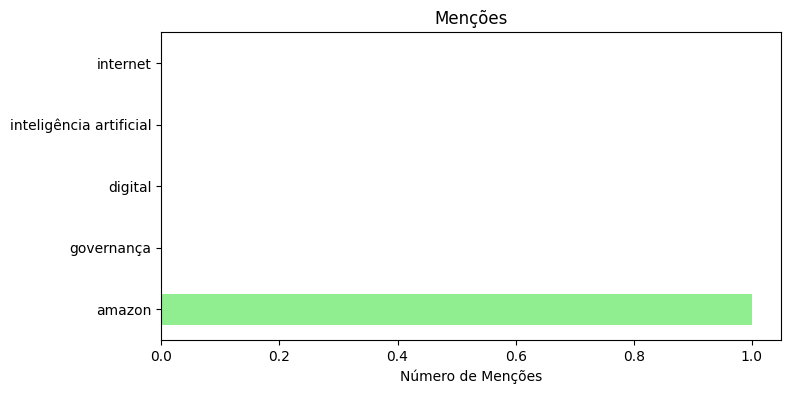

In [ ]:
termos = ['governança', 'digital', 'inteligência artificial', 'internet' , 'amazon']
frequencia = {}

for termo in termos:
    # Conta em quantos títulos a palavra aparece
    frequencia[termo] = df_artigos_ministros['texto_completo'].str.contains(termo, case=False).sum()

# Converter para série para facilitar a plotagem
ser_freq = pd.Series(frequencia)

plt.figure(figsize=(8, 4))
ser_freq.sort_values(ascending=False).plot(kind='barh', color='lightgreen')
plt.title('Menções')
plt.xlabel('Número de Menções')
plt.show()

# Entrevistas

## Ministros

In [ ]:
ministros = ['mauro-vieira' , 'carlos-alberto-franco-franca' , 'ernesto-araujo' , 'aloysio-nunes-ferreira' , 'jose-serra' , 'mauro-vieira-2015-2016' , 'luis-alberto-figueiredo-machado']
pattern = '|'.join(ministros)
df_entrevistas_ministros = df_entrevistas[(df_entrevistas['extra_01'].astype(str).str.contains('ministro-das-relacoes-exteriores')) & (df_entrevistas['autoria'].astype(str).str.contains(pattern))]
df_entrevistas_ministros

,tipo_dado,pais,origem,sigla,classificado,categoria,autoria,titulo,subtitulo,data,...,extra_02,extra_03,data_dt,texto,texto_completo,hora_int,ano_mes,dia_semana,tamanho_texto,qtd_paragrafos
652,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,entrevistas,mauro-vieira-2023,Acordo do Uruguai com a China seria destruição...,Entrevista concedida pelo Senhor Ministro de E...,21/01/2023,...,NA,NA,2023-01-21,Um acordo de livre comércio entre Uruguai e Ch...,acordo do uruguai com a china seria destruição...,0.0,2023-01,Saturday,203,0
653,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,entrevistas,mauro-vieira-2023,Mauro Vieira: “Un mundo más multipolar siempre...,NA,21/01/2023,...,NA,NA,2023-01-21,Tras los ataques por parte de bolsonaristas a ...,mauro vieira: “un mundo más multipolar siempre...,0.0,2023-01,Saturday,382,0
654,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,entrevistas,mauro-vieira-2023,La relación bilateral con Argentina vuelve a s...,NA,20/01/2023,...,NA,NA,2023-01-20,"El flamante canciller de Brasil, Mauro Vieira,...",la relación bilateral con argentina vuelve a s...,0.0,2023-01,Friday,461,0
655,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,entrevistas,mauro-vieira-2023,"Mauro Vieira, ministro de Exteriores de Brasil...",El nuevo canciller del Gobierno de Lula tiene ...,13/01/2023,...,NA,NA,2023-01-13,Naiara Galarraga Gortázar,"mauro vieira, ministro de exteriores de brasil...",0.0,2023-01,Friday,25,0
656,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,entrevistas,mauro-vieira-2023,"Brasil defende diálogo com Putin (Le Monde, Fr...",Entrevista concedida pelo Senhor Ministro de E...,06/01/2023,...,NA,NA,2023-01-06,"""O Brasil está de volta!"" Foi com essas palavr...","brasil defende diálogo com putin (le monde, fr...",0.0,2023-01,Friday,539,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,entrevistas,ernesto-araujo-2019-2021,Ernesto Araújo: Brasileiros não abandonam refo...,NA,13/05/2019,...,NA,NA,2019-05-13,https://www.rp.pl/Polityka/305129957-Ernesto-A...,ernesto araújo: brasileiros não abandonam refo...,19.0,2019-05,Monday,91,0
2019,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,entrevistas,ernesto-araujo-2019-2021,Brasil-Hungria: Araújo diz que Brasil manterá ...,NA,10/05/2019,...,NA,NA,2019-05-10,https://www.efe.com/efe/brasil/brasil/araujo-d...,brasil-hungria: araújo diz que brasil manterá ...,20.0,2019-05,Friday,124,0
2020,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,entrevistas,ernesto-araujo-2019-2021,Chanceler Ernesto Araújo fala em sua visita à ...,NA,10/05/2019,...,NA,NA,2019-05-10,,chanceler ernesto araújo fala em sua visita à ...,19.0,2019-05,Friday,0,0
2021,aberto,Brasil,Ministério das Relações Exteriores,BD_DE_LATAM_BRA_GOVFEDERAL_MRE_DISCURSOS_ARTIG...,NA,entrevistas,ernesto-araujo-2019-2021,Araújo: «No combate à soberania para salvar na...,NA,08/05/2019,...,NA,NA,2019-05-08,Araújo: «Combattere il sovranismo per salvare ...,araújo: «no combate à soberania para salvar na...,19.0,2019-05,Wednesday,130,0


In [ ]:
# Extrair apenas o ano
df_entrevistas_ministros["ano"] = df_entrevistas_ministros["data_dt"].dt.year

entrevistas_por_ano_ministros = df_entrevistas_ministros['ano'].value_counts().sort_index()

display(entrevistas_por_ano_ministros)

/tmp/ipykernel_597/3020399282.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_entrevistas_ministros["ano"] = df_entrevistas_ministros["data_dt"].dt.year


,count
ano,
2015,1
2016,8
2019,29
2020,5
2021,1
2023,40
2024,4
2025,6


### Análise de palavras chave

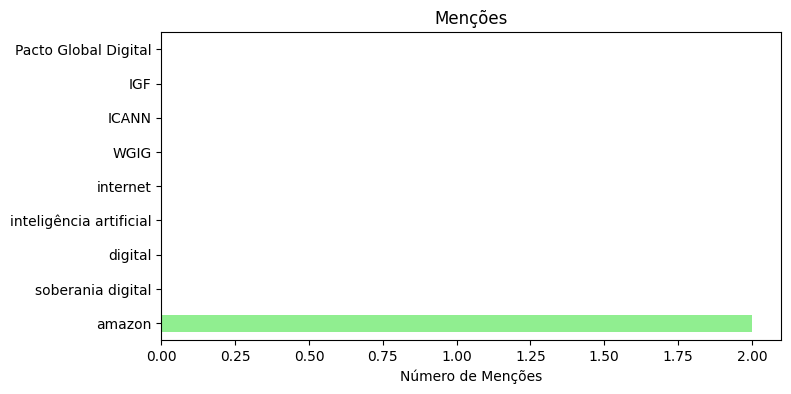

In [ ]:
termos = ['soberania digital', 'digital', 'inteligência artificial', 'internet', 'amazon', 'WGIG' , 'ICANN' , 'IGF' , 'Pacto Global Digital']
frequencia = {}

for termo in termos:
    # Conta em quantos títulos a palavra aparece
    frequencia[termo] = df_entrevistas_ministros['texto_completo'].str.contains(termo, case=False).sum()

# Converter para série para facilitar a plotagem
ser_freq = pd.Series(frequencia)

plt.figure(figsize=(8, 4))
ser_freq.sort_values(ascending=False).plot(kind='barh', color='lightgreen')
plt.title('Menções')
plt.xlabel('Número de Menções')
plt.show()

In [ ]:
df_customizado_entrevistas_ministros = df_entrevistas_ministros [["autoria","titulo",
       "data_atualizado", "horario_atualizado", "link", "paragrafos", "texto_completo","data_dt", "hora_int", "qtd_paragrafos", "tamanho_texto"]]
df_customizado_entrevistas_ministros

,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto
652,mauro-vieira-2023,Acordo do Uruguai com a China seria destruição...,27/06/2023,15h03,https://www.gov.br/mre/pt-br/centrais-de-conte...,Um acordo de livre comércio entre Uruguai e Ch...,acordo do uruguai com a china seria destruição...,2023-01-21,0.0,0,203
653,mauro-vieira-2023,Mauro Vieira: “Un mundo más multipolar siempre...,08/11/2023,12h35,https://www.gov.br/mre/pt-br/centrais-de-conte...,Tras los ataques por parte de bolsonaristas a ...,mauro vieira: “un mundo más multipolar siempre...,2023-01-21,0.0,0,382
654,mauro-vieira-2023,La relación bilateral con Argentina vuelve a s...,08/11/2023,12h37,https://www.gov.br/mre/pt-br/centrais-de-conte...,"El flamante canciller de Brasil, Mauro Vieira,...",la relación bilateral con argentina vuelve a s...,2023-01-20,0.0,0,461
655,mauro-vieira-2023,"Mauro Vieira, ministro de Exteriores de Brasil...",08/11/2023,12h39,https://www.gov.br/mre/pt-br/centrais-de-conte...,Naiara Galarraga Gortázar,"mauro vieira, ministro de exteriores de brasil...",2023-01-13,0.0,0,25
656,mauro-vieira-2023,"Brasil defende diálogo com Putin (Le Monde, Fr...",10/04/2025,15h24,https://www.gov.br/mre/pt-br/centrais-de-conte...,"""O Brasil está de volta!"" Foi com essas palavr...","brasil defende diálogo com putin (le monde, fr...",2023-01-06,0.0,0,539
...,...,...,...,...,...,...,...,...,...,...,...
2018,ernesto-araujo-2019-2021,Ernesto Araújo: Brasileiros não abandonam refo...,27/06/2023,15h29,https://www.gov.br/mre/pt-br/centrais-de-conte...,https://www.rp.pl/Polityka/305129957-Ernesto-A...,ernesto araújo: brasileiros não abandonam refo...,2019-05-13,19.0,0,91
2019,ernesto-araujo-2019-2021,Brasil-Hungria: Araújo diz que Brasil manterá ...,27/06/2023,15h31,https://www.gov.br/mre/pt-br/centrais-de-conte...,https://www.efe.com/efe/brasil/brasil/araujo-d...,brasil-hungria: araújo diz que brasil manterá ...,2019-05-10,20.0,0,124
2020,ernesto-araujo-2019-2021,Chanceler Ernesto Araújo fala em sua visita à ...,27/06/2023,15h06,https://www.gov.br/mre/pt-br/centrais-de-conte...,,chanceler ernesto araújo fala em sua visita à ...,2019-05-10,19.0,0,0
2021,ernesto-araujo-2019-2021,Araújo: «No combate à soberania para salvar na...,27/06/2023,15h06,https://www.gov.br/mre/pt-br/centrais-de-conte...,Araújo: «Combattere il sovranismo per salvare ...,araújo: «no combate à soberania para salvar na...,2019-05-08,19.0,0,130


In [ ]:
def buscar_termo(termo, onde='completo'):
    """
    Busca um termo nas notas do MRE.

    Parâmetros:
        termo (str): palavra ou expressão a buscar (não diferencia maiúsc/minúsc)
        onde (str): 'titulo', 'texto' ou 'completo' (título + corpo)

    Retorna:
        DataFrame com as notas que contêm o termo
    """
    coluna = {
        'titulo': 'titulo',
        'texto': 'texto',
        'completo': 'texto_completo',
    }[onde]

    # busca case-insensitive; na=False ignora valores faltantes
    mascara = df_customizado_entrevistas_ministros[coluna].str.contains(termo, case=False, na=False, regex=False)
    resultado = df_customizado_entrevistas_ministros[mascara].sort_values('data_dt', ascending=False)

    print(f"🔎 Termo: '{termo}'  |  Onde: {onde}")
    print(f"📌 Notas encontradas: {len(resultado)} de {len(df_customizado_entrevistas_ministros)} ({len(resultado)/len(df_customizado_entrevistas_ministros)*100:.1f}%)")
    print("-" * 60)

    for _, row in resultado.iterrows():
        data_str = row['data_dt'].strftime('%d/%m/%Y') if pd.notna(row['data_dt']) else '?'
        print(f"  • [{data_str}] {row['titulo']}")

    return resultado

In [ ]:
buscar_termo('amazon', onde='completo')

🔎 Termo: 'amazon'  |  Onde: completo
📌 Notas encontradas: 2 de 94 (2.1%)
------------------------------------------------------------
  • [05/09/2019] A importância de termos fatos reais sobre incêndios na Amazônia – Entrevista do Ministro Ernesto Araújo a Andrés Oppenheimer (CNN en Español, 05/09/19)
  • [04/09/2019] Brazilian FM: The Amazon is not burning (CNN, 04/09/2019) [English]


,autoria,titulo,data_atualizado,horario_atualizado,link,paragrafos,texto_completo,data_dt,hora_int,qtd_paragrafos,tamanho_texto
836,ernesto-araujo-2019-2021,A importância de termos fatos reais sobre incê...,27/06/2023,15h20,https://www.gov.br/mre/pt-br/centrais-de-conte...,Veja a entrevista em: https://www.youtube.com/...,a importância de termos fatos reais sobre incê...,2019-09-05,20.0,0,217
839,ernesto-araujo-2019-2021,"Brazilian FM: The Amazon is not burning (CNN, ...",27/06/2023,15h34,https://www.gov.br/mre/pt-br/centrais-de-conte...,https://edition.cnn.com/videos/tv/2019/09/04/a...,"brazilian fm: the amazon is not burning (cnn, ...",2019-09-04,20.0,0,112


### Co-ocorrência de palavras

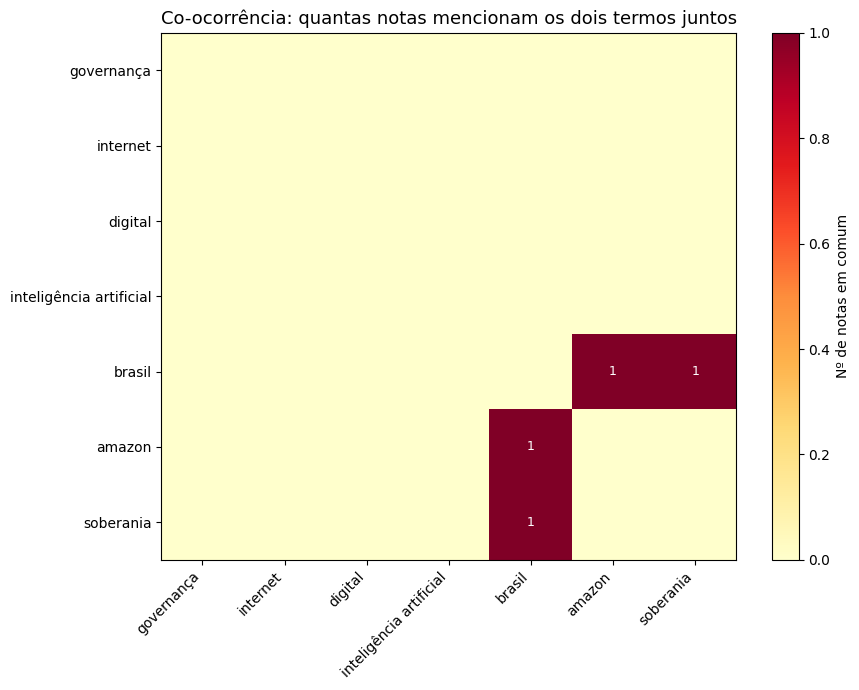

In [ ]:
import numpy as np

palavras_analise = ['governança', 'internet' , 'digital' , 'inteligência artificial', 'brasil', 'amazon', 'soberania']

# Para cada nota, marca quais países são mencionados
matriz_presenca = pd.DataFrame({
    palavra: df_entrevistas_ministros['texto_completo'].str.contains(palavra, case=False, na=False, regex=False).astype(int)
    for palavra in palavras_analise
})

# Matriz de co-ocorrência (multiplicação matricial: notas onde A E B aparecem)
coocorrencia = matriz_presenca.T.dot(matriz_presenca)

# Zerar a diagonal (não interessa um país com ele mesmo)
np.fill_diagonal(coocorrencia.values, 0)

# Heatmap simples com matplotlib
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(coocorrencia, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(palavras_analise)))
ax.set_yticks(range(len(palavras_analise)))
ax.set_xticklabels(palavras_analise, rotation=45, ha='right')
ax.set_yticklabels(palavras_analise)
ax.set_title('Co-ocorrência: quantas notas mencionam os dois termos juntos', fontsize=13)

# Anotar os valores nas células
for i in range(len(palavras_analise)):
    for j in range(len(palavras_analise)):
        valor = coocorrencia.iloc[i, j]
        if valor > 0:
            ax.text(j, i, int(valor), ha='center', va='center',
                    color='black' if valor < coocorrencia.values.max()/2 else 'white',
                    fontsize=9)

plt.colorbar(im, ax=ax, label='Nº de notas em comum')
plt.tight_layout()
plt.show()

multilateral

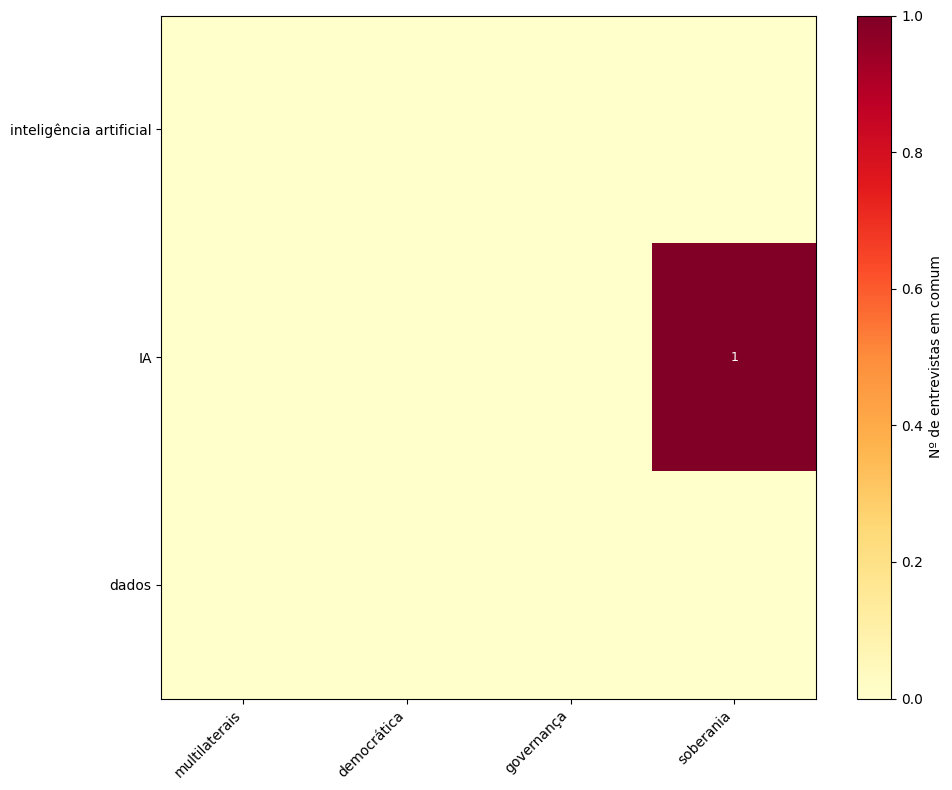

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Definir as palavras para os eixos vertical e horizontal
palavras_vertical = ['inteligência artificial', 'IA', 'dados']
palavras_horizontal = ['multilaterais','democrática', 'governança', 'soberania']

# Combinar todas as palavras para criar a matriz de presença inicial
palavras_analise_total = list(set(palavras_vertical + palavras_horizontal))

# Para cada nota, marca quais palavras são mencionadas
matriz_presenca = pd.DataFrame({
    palavra: df_entrevistas_ministros['texto_completo'].str.contains(palavra, case=False, na=False, regex=False).astype(int)
    for palavra in palavras_analise_total
})

# Matriz de co-ocorrência entre os dois conjuntos de palavras
# Linhas: palavras_vertical, Colunas: palavras_horizontal
coocorrencia_personalizada = matriz_presenca[palavras_vertical].T.dot(matriz_presenca[palavras_horizontal])

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(coocorrencia_personalizada, cmap='YlOrRd', aspect='auto')

# Configurar os rótulos dos eixos
ax.set_xticks(range(len(palavras_horizontal)))
ax.set_yticks(range(len(palavras_vertical)))
ax.set_xticklabels(palavras_horizontal, rotation=45, ha='right')
ax.set_yticklabels(palavras_vertical)

# Anotar os valores nas células
for i in range(len(palavras_vertical)):
    for j in range(len(palavras_horizontal)):
        valor = coocorrencia_personalizada.iloc[i, j]
        if valor > 0:
            ax.text(j, i, int(valor), ha='center', va='center',
                    color='black' if valor < coocorrencia_personalizada.values.max()/2 else 'white',
                    fontsize=9)

plt.colorbar(im, ax=ax, label='Nº de entrevistas em comum')
plt.tight_layout()
plt.show()

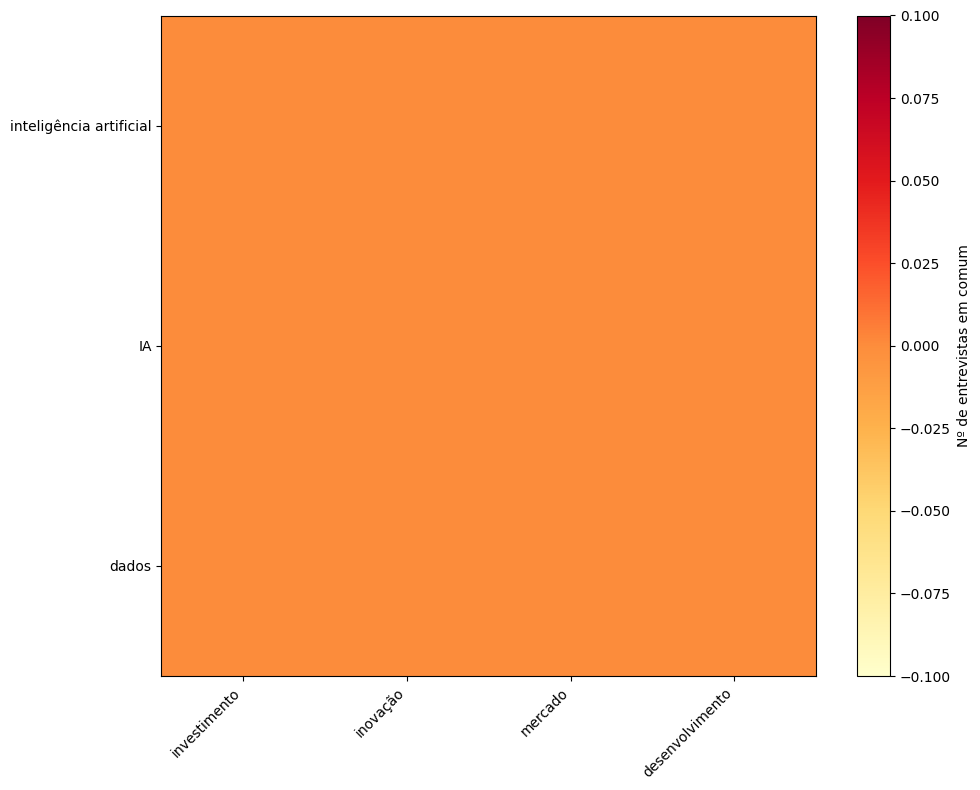

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Definir as palavras para os eixos vertical e horizontal
palavras_vertical = ['inteligência artificial', 'IA', 'dados']
palavras_horizontal = ["investimento", "inovação", "mercado", "desenvolvimento"]


# Combinar todas as palavras para criar a matriz de presença inicial
palavras_analise_total = list(set(palavras_vertical + palavras_horizontal))

# Para cada nota, marca quais palavras são mencionadas
matriz_presenca = pd.DataFrame({
    palavra: df_entrevistas_ministros['texto_completo'].str.contains(palavra, case=False, na=False, regex=False).astype(int)
    for palavra in palavras_analise_total
})

# Matriz de co-ocorrência entre os dois conjuntos de palavras
# Linhas: palavras_vertical, Colunas: palavras_horizontal
coocorrencia_personalizada = matriz_presenca[palavras_vertical].T.dot(matriz_presenca[palavras_horizontal])

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(coocorrencia_personalizada, cmap='YlOrRd', aspect='auto')

# Configurar os rótulos dos eixos
ax.set_xticks(range(len(palavras_horizontal)))
ax.set_yticks(range(len(palavras_vertical)))
ax.set_xticklabels(palavras_horizontal, rotation=45, ha='right')
ax.set_yticklabels(palavras_vertical)

# Anotar os valores nas células
for i in range(len(palavras_vertical)):
    for j in range(len(palavras_horizontal)):
        valor = coocorrencia_personalizada.iloc[i, j]
        if valor > 0:
            ax.text(j, i, int(valor), ha='center', va='center',
                    color='black' if valor < coocorrencia_personalizada.values.max()/2 else 'white',
                    fontsize=9)

plt.colorbar(im, ax=ax, label='Nº de entrevistas em comum')
plt.tight_layout()
plt.show()

multissetorial

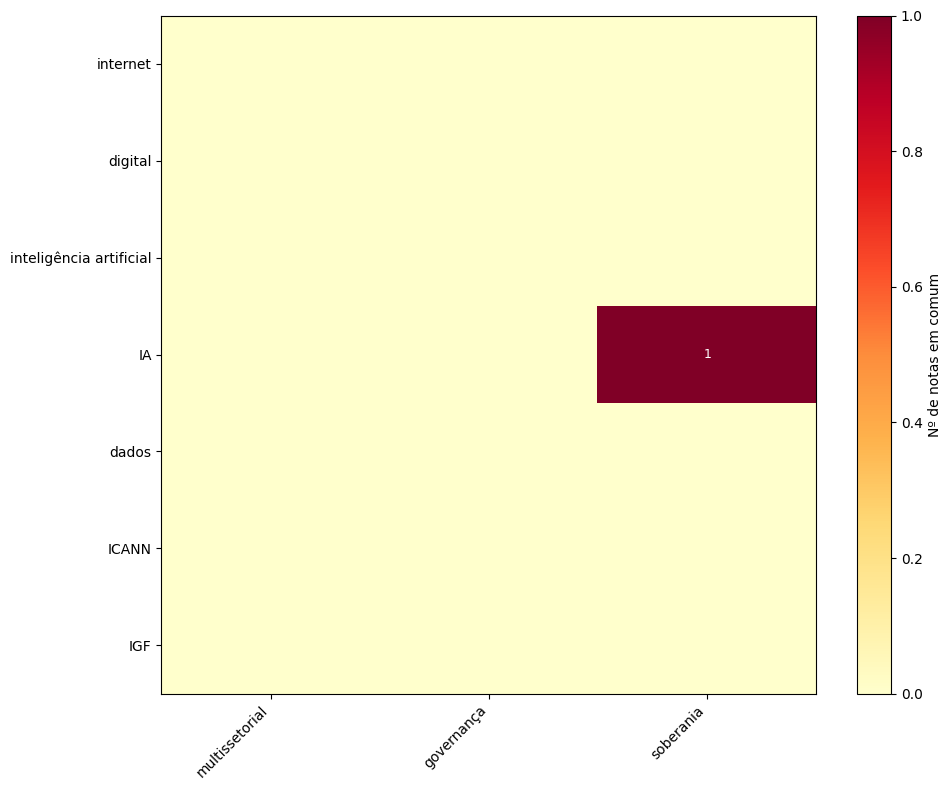

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Definir as palavras para os eixos vertical e horizontal
palavras_vertical = ['internet', 'digital', 'inteligência artificial', 'IA', 'dados', 'ICANN', 'IGF']
palavras_horizontal = ['multissetorial', 'governança', 'soberania']

# Combinar todas as palavras para criar a matriz de presença inicial
palavras_analise_total = list(set(palavras_vertical + palavras_horizontal))

# Para cada nota, marca quais palavras são mencionadas
matriz_presenca = pd.DataFrame({
    palavra: df_entrevistas_ministros['texto_completo'].str.contains(palavra, case=False, na=False, regex=False).astype(int)
    for palavra in palavras_analise_total
})

# Matriz de co-ocorrência entre os dois conjuntos de palavras
# Linhas: palavras_vertical, Colunas: palavras_horizontal
coocorrencia_personalizada = matriz_presenca[palavras_vertical].T.dot(matriz_presenca[palavras_horizontal])

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(coocorrencia_personalizada, cmap='YlOrRd', aspect='auto')

# Configurar os rótulos dos eixos
ax.set_xticks(range(len(palavras_horizontal)))
ax.set_yticks(range(len(palavras_vertical)))
ax.set_xticklabels(palavras_horizontal, rotation=45, ha='right')
ax.set_yticklabels(palavras_vertical)

# Anotar os valores nas células
for i in range(len(palavras_vertical)):
    for j in range(len(palavras_horizontal)):
        valor = coocorrencia_personalizada.iloc[i, j]
        if valor > 0:
            ax.text(j, i, int(valor), ha='center', va='center',
                    color='black' if valor < coocorrencia_personalizada.values.max()/2 else 'white',
                    fontsize=9)

plt.colorbar(im, ax=ax, label='Nº de notas em comum')
plt.tight_layout()
plt.show()

## Secretaria-geral

In [ ]:
secretaria = ['maria-laura-da-rocha-2023' , 'fernando-simas-magalhaes' , 'otavio-brandelli-2019-2021' , 'marcos-bezerra-abbott-galvao-2016-2018' , 'sergio-franca-danese-2015-2016' , 'eduardo-dos-santos-2013-2015']
pattern = '|'.join(secretaria)
df_entrevistas_secretaria = df_entrevistas[(df_entrevistas['extra_01'].astype(str).str.contains('secretario-geral')) & (df_entrevistas['autoria'].astype(str).str.contains(pattern))]
df_entrevistas_secretaria

,tipo_dado,pais,origem,sigla,classificado,categoria,autoria,titulo,subtitulo,data,...,extra_02,extra_03,data_dt,texto,texto_completo,hora_int,ano_mes,dia_semana,tamanho_texto,qtd_paragrafos


### Análise de palavras chave

multilateral

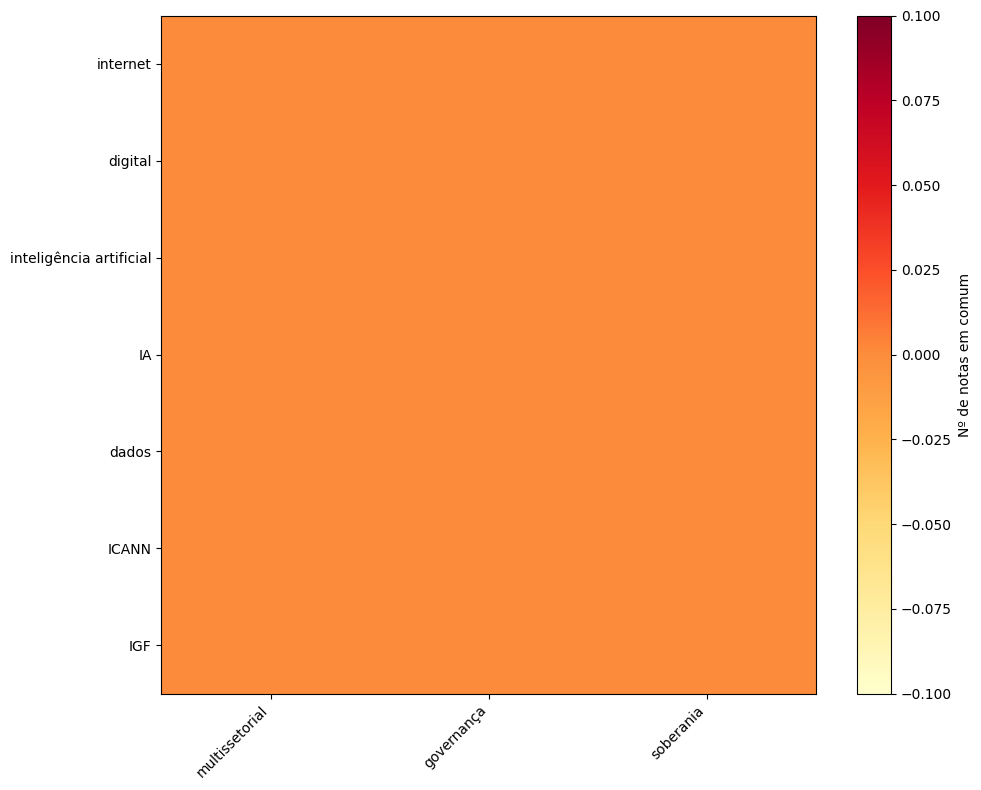

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Definir as palavras para os eixos vertical e horizontal
palavras_vertical = ['internet', 'digital', 'inteligência artificial', 'IA', 'dados', 'ICANN', 'IGF']
palavras_horizontal = ['multissetorial', 'governança', 'soberania']

# Combinar todas as palavras para criar a matriz de presença inicial
palavras_analise_total = list(set(palavras_vertical + palavras_horizontal))

# Para cada nota, marca quais palavras são mencionadas
matriz_presenca = pd.DataFrame({
    palavra: df_entrevistas_secretaria['texto_completo'].str.contains(palavra, case=False, na=False, regex=False).astype(int)
    for palavra in palavras_analise_total
})

# Matriz de co-ocorrência entre os dois conjuntos de palavras
# Linhas: palavras_vertical, Colunas: palavras_horizontal
coocorrencia_personalizada = matriz_presenca[palavras_vertical].T.dot(matriz_presenca[palavras_horizontal])

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(coocorrencia_personalizada, cmap='YlOrRd', aspect='auto')

# Configurar os rótulos dos eixos
ax.set_xticks(range(len(palavras_horizontal)))
ax.set_yticks(range(len(palavras_vertical)))
ax.set_xticklabels(palavras_horizontal, rotation=45, ha='right')
ax.set_yticklabels(palavras_vertical)

# Anotar os valores nas células
for i in range(len(palavras_vertical)):
    for j in range(len(palavras_horizontal)):
        valor = coocorrencia_personalizada.iloc[i, j]
        if valor > 0:
            ax.text(j, i, int(valor), ha='center', va='center',
                    color='black' if valor < coocorrencia_personalizada.values.max()/2 else 'white',
                    fontsize=9)

plt.colorbar(im, ax=ax, label='Nº de notas em comum')
plt.tight_layout()
plt.show()